ANÁLISIS EXPLORATORIO DE DATOS — N-CMAPSS DS01

Archivo: N-CMAPSS_DS01-005.h5

Filtro global: Motor 2 · Clase de vuelo 3 (Fc = 3)

Entorno: Python 3.11, conda-forge

Dependencias: h5py, numpy, pandas, matplotlib, seaborn, scipy

Instalación (si es necesario):

  conda install -c conda-forge h5py numpy pandas matplotlib seaborn scipy

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

# FILE_PATH = r"C:\Users\11jav\Documents\Master\TFM\Dataset_Nasa\Turbofan_Engine_degradation\Datasets\data_set\data_set\N-CMAPSS_DS01-005.h5"

FILE_PATH = r"N-CMAPSS_DS01-005.h5"
MOTOR     = 2       # motor analizado en todo el notebook
FC        = 3       # clase de vuelo analizada en todo el notebook


## Sección 1 — Carga, Estructura y Filtrado (Motor 2 · Fc=3)

Cargamos el archivo HDF5 y aplicamos el filtro global (Motor=2, Fc=3) inmediatamente después de construir los DataFrames. La variable `hs` (health state) se excluye: no es observable en un motor real y su inclusión en el análisis exploratorio introduciría información que no estaría disponible en un sistema de monitorización real.

In [2]:
print("=" * 60)
print("SECCIÓN 1 — CARGA Y FILTRADO")
print(f"  Motor: {MOTOR}  |  Clase de vuelo: {FC}")
print("=" * 60)

with h5py.File(FILE_PATH, 'r') as f:

    print("\nClaves disponibles en el archivo HDF5:")
    for key in f.keys():
        arr = np.array(f[key])
        print(f"  {key:15s} → shape: {str(arr.shape):20s}  dtype: {arr.dtype}")

    W_dev    = np.array(f['W_dev'])
    X_s_dev  = np.array(f['X_s_dev'])
    Y_dev    = np.array(f['Y_dev'])
    A_dev    = np.array(f['A_dev'])

    W_test   = np.array(f['W_test'])
    X_s_test = np.array(f['X_s_test'])
    Y_test   = np.array(f['Y_test'])
    A_test   = np.array(f['A_test'])

    W_var  = [v.decode() for v in f['W_var'][:]]
    Xs_var = [v.decode() for v in f['X_s_var'][:]]
    A_var  = [v.decode() for v in f['A_var'][:]]


SECCIÓN 1 — CARGA Y FILTRADO
  Motor: 2  |  Clase de vuelo: 3

Claves disponibles en el archivo HDF5:
  A_dev           → shape: (4906636, 4)          dtype: float64
  A_test          → shape: (2735232, 4)          dtype: float64
  A_var           → shape: (4,)                  dtype: |S5
  T_dev           → shape: (4906636, 10)         dtype: float64
  T_test          → shape: (2735232, 10)         dtype: float64
  T_var           → shape: (10,)                 dtype: |S12
  W_dev           → shape: (4906636, 4)          dtype: float64
  W_test          → shape: (2735232, 4)          dtype: float64
  W_var           → shape: (4,)                  dtype: |S4
  X_s_dev         → shape: (4906636, 14)         dtype: float64
  X_s_test        → shape: (2735232, 14)         dtype: float64
  X_s_var         → shape: (14,)                 dtype: |S4
  X_v_dev         → shape: (4906636, 14)         dtype: float64
  X_v_test        → shape: (2735232, 14)         dtype: float64
  X_v_var        

In [3]:
# A_var incluye 'hs' — lo excluimos de todas las columnas de análisis

A_var_use = [v for v in A_var if v != 'hs']
print(f"\nVariables cargadas (hs excluido):")
print(f"  Auxiliares usadas (A): {A_var_use}")
print(f"  Escenario         (W): {W_var}")
print(f"  Sensores         (Xs): {Xs_var}")


Variables cargadas (hs excluido):
  Auxiliares usadas (A): ['unit', 'cycle', 'Fc']
  Escenario         (W): ['alt', 'Mach', 'TRA', 'T2']
  Sensores         (Xs): ['T24', 'T30', 'T48', 'T50', 'P15', 'P2', 'P21', 'P24', 'Ps30', 'P40', 'P50', 'Nf', 'Nc', 'Wf']


In [4]:
# Índice de columnas hs en A para excluirlo al construir el DataFrame

hs_idx   = A_var.index('hs') if 'hs' in A_var else None
A_var_nhs = [v for v in A_var if v != 'hs']
if hs_idx is not None:
    A_dev_use  = np.delete(A_dev,  hs_idx, axis=1)
    A_test_use = np.delete(A_test, hs_idx, axis=1)
else:
    A_dev_use  = A_dev
    A_test_use = A_test

all_cols = A_var_nhs + W_var + Xs_var + ['RUL']

df_dev_full = pd.DataFrame(
    np.hstack([A_dev_use, W_dev, X_s_dev, Y_dev.reshape(-1, 1)]),
    columns=all_cols
)
df_test_full = pd.DataFrame(
    np.hstack([A_test_use, W_test, X_s_test, Y_test.reshape(-1, 1)]),
    columns=all_cols
)

for col in ['unit', 'cycle', 'Fc']:
    df_dev_full[col]  = df_dev_full[col].astype(int)
    df_test_full[col] = df_test_full[col].astype(int)

# ── FILTRO GLOBAL: Motor=2, Fc=3

df_dev  = df_dev_full[ (df_dev_full['unit']  == MOTOR) & (df_dev_full['Fc']  == FC)].copy()
df_test = df_test_full[(df_test_full['unit'] == MOTOR) & (df_test_full['Fc'] == FC)].copy()

df_dev  = df_dev.sort_values('cycle').reset_index(drop=True)
df_test = df_test.sort_values('cycle').reset_index(drop=True)

print(f"\nDataset tras filtrar Motor={MOTOR}, Fc={FC}:")
print(f"  Desarrollo : {len(df_dev):>8,} filas  |  ciclos {df_dev['cycle'].min()}–{df_dev['cycle'].max()}")
print(f"  Prueba     : {len(df_test):>8,} filas  |  ciclos {df_test['cycle'].min()}–{df_test['cycle'].max()}")
print(f"  RUL rango  : [{df_dev['RUL'].min():.0f}, {df_dev['RUL'].max():.0f}] ciclos")
print(f"\nPrimeras filas:")
print(df_dev.head())

# Alias de colores (solo Fc=3 en este análisis)
fc_colors     = {FC: '#4CAF50'}
legend_elements = []   # sin leyenda multi-Fc necesaria


Dataset tras filtrar Motor=2, Fc=3:
  Desarrollo : 1,049,088 filas  |  ciclos 1–75
  Prueba     :        0 filas  |  ciclos nan–nan
  RUL rango  : [0, 74] ciclos

Primeras filas:
   unit  cycle  Fc      alt      Mach        TRA          T2         T24  \
0     2      1   3   3006.0  0.344799  79.804123  520.027791  624.824640   
1     2      1   3  30527.0  0.717003  63.368690  451.942060  527.102322   
2     2      1   3  30522.0  0.717066  63.368690  451.968047  527.127871   
3     2      1   3  30518.0  0.716940  63.368690  451.969509  527.131873   
4     2      1   3  30514.0  0.716940  63.368690  451.985486  527.149146   

           T30          T48  ...         P2        P21        P24        Ps30  \
0  1503.520055  1916.389834  ...  14.260590  20.019116  25.180934  425.013842   
1  1235.636838  1513.470047  ...   5.988970   7.846121   9.637288  142.241780   
2  1235.672061  1513.724586  ...   5.990615   7.848065   9.639598  142.272017   
3  1235.710294  1513.634633  ...   5.99

## Sección 2 — Inspección General: Nulos, Tipos y Estadísticos Básicos

El dataset es simulado (C-MAPSS), por lo que no esperamos valores nulos. El coeficiente de variación (CV = std / |media|) permite comparar la dispersión relativa entre sensores con escalas muy distintas. Sensores con CV < 0.001 son casi constantes y de escaso valor predictivo.

In [6]:
print("SECCIÓN 2 — INSPECCIÓN GENERAL")

nulls = df_dev.isnull().sum()
print("\nValores nulos:")
print(nulls[nulls > 0] if nulls.sum() > 0 else "  → No se detectan valores nulos.")

desc = df_dev.describe().T
desc['cv'] = desc['std'] / desc['mean'].abs()
print("\nEstadísticos descriptivos:")
print(desc[['mean', 'std', 'cv', 'min', '25%', '50%', '75%', 'max']].round(4))

cv_sensors = df_dev[Xs_var].std() / df_dev[Xs_var].mean().abs()
low_var = cv_sensors[cv_sensors < 0.001]
print("\nSensores con varianza casi nula (CV < 0.001):")
print(low_var if len(low_var) > 0 else "  → Todos los sensores presentan varianza significativa.")

SECCIÓN 2 — INSPECCIÓN GENERAL

Valores nulos:
  → No se detectan valores nulos.

Estadísticos descriptivos:
             mean        std      cv        min         25%         50%  \
unit       2.0000     0.0000  0.0000     2.0000      2.0000      2.0000   
cycle     38.0017    21.6718  0.5703     1.0000     19.0000     39.0000   
Fc         3.0000     0.0000  0.0000     3.0000      3.0000      3.0000   
alt    18989.1529  8403.2103  0.4425  3001.0000  11708.7500  20632.0000   
Mach       0.5794     0.1184  0.2044     0.1992      0.5127      0.6082   
TRA       64.9740    17.7632  0.2734    23.8182     51.4156     73.2124   
T2       481.7596    21.0944  0.0438   421.3779    464.1133    478.7396   
T24      563.7346    21.4047  0.0380   484.1972    549.1378    560.4721   
T30     1324.1729    65.0544  0.0491  1070.7188   1284.3426   1320.2906   
T48     1642.0272   116.0552  0.0707   955.0565   1578.1848   1652.2216   
T50     1117.5267    61.9358  0.0554   698.4278   1076.4938   1104

## Sección 3 — Ciclos de Vida y Distribución Temporal (Motor 2 · Fc=3)

Con el filtro aplicado trabajamos con un único motor y una única clase de vuelo, por lo que el análisis se centra en la distribución temporal de los ciclos y la evolución del RUL a lo largo de la vida del motor.


SECCIÓN 3 — CICLOS DE VIDA  (Motor 2 · Fc=3)

Ciclos únicos : 75
  Primer ciclo     : 1
  Último ciclo     : 75
  Observaciones    : 1,049,088  (13987 obs/ciclo aprox.)

Observaciones por ciclo:
  Min: 9649  |  Max: 20294  |  Media: 13987.8


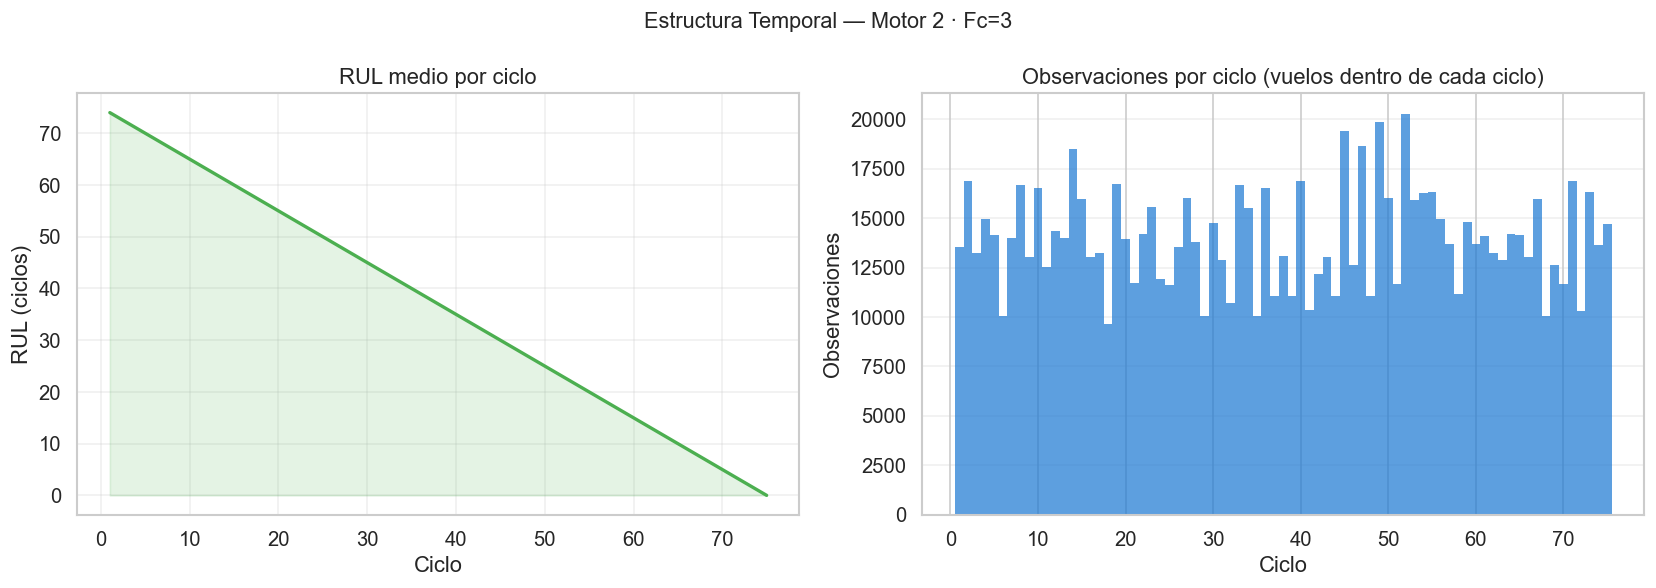

In [7]:
print("\n" + "=" * 60)
print(f"SECCIÓN 3 — CICLOS DE VIDA  (Motor {MOTOR} · Fc={FC})")
print("=" * 60)

n_ciclos = df_dev['cycle'].nunique()
print(f"\nCiclos únicos : {n_ciclos}")
print(f"  Primer ciclo     : {df_dev['cycle'].min()}")
print(f"  Último ciclo     : {df_dev['cycle'].max()}")
print(f"  Observaciones    : {len(df_dev):,}  ({len(df_dev)//n_ciclos:.0f} obs/ciclo aprox.)")

# Observaciones por ciclo
obs_per_cycle = df_dev.groupby('cycle').size()
print(f"\nObservaciones por ciclo:")
print(f"  Min: {obs_per_cycle.min()}  |  Max: {obs_per_cycle.max()}  |  Media: {obs_per_cycle.mean():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Estructura Temporal — Motor {MOTOR} · Fc={FC}', fontsize=13)

axes[0].plot(df_dev.groupby('cycle')['RUL'].mean(), color='#4CAF50', lw=2)
axes[0].fill_between(df_dev.groupby('cycle')['RUL'].mean().index,
                     df_dev.groupby('cycle')['RUL'].mean().values,
                     alpha=0.15, color='#4CAF50')
axes[0].set_xlabel('Ciclo')
axes[0].set_ylabel('RUL (ciclos)')
axes[0].set_title('RUL medio por ciclo')
axes[0].grid(alpha=0.3)

axes[1].bar(obs_per_cycle.index, obs_per_cycle.values, color='#1976D2',
            width=1.0, edgecolor='none', alpha=0.7)
axes[1].set_xlabel('Ciclo')
axes[1].set_ylabel('Observaciones')
axes[1].set_title('Observaciones por ciclo (vuelos dentro de cada ciclo)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Sección 4 — Análisis del RUL (Motor 2 · Fc=3)

El RUL (Remaining Useful Life) es la variable objetivo: ciclos de vuelo restantes hasta el fallo. En N-CMAPSS es lineal por construcción. La distribución es uniforme (un punto por ciclo), lo que confirma que no hay aceleración visible del fallo en el RUL crudo — la degradación real está capturada en los parámetros T (HPT_eff_mod principalmente).


SECCIÓN 4 — ANÁLISIS DEL RUL  (Motor 2 · Fc=3)

Estadísticos del RUL:
  Mínimo : 0 ciclos
  Máximo : 74 ciclos
  Media  : 37.0 ciclos
  Mediana: 36.0 ciclos
  Std    : 21.7 ciclos


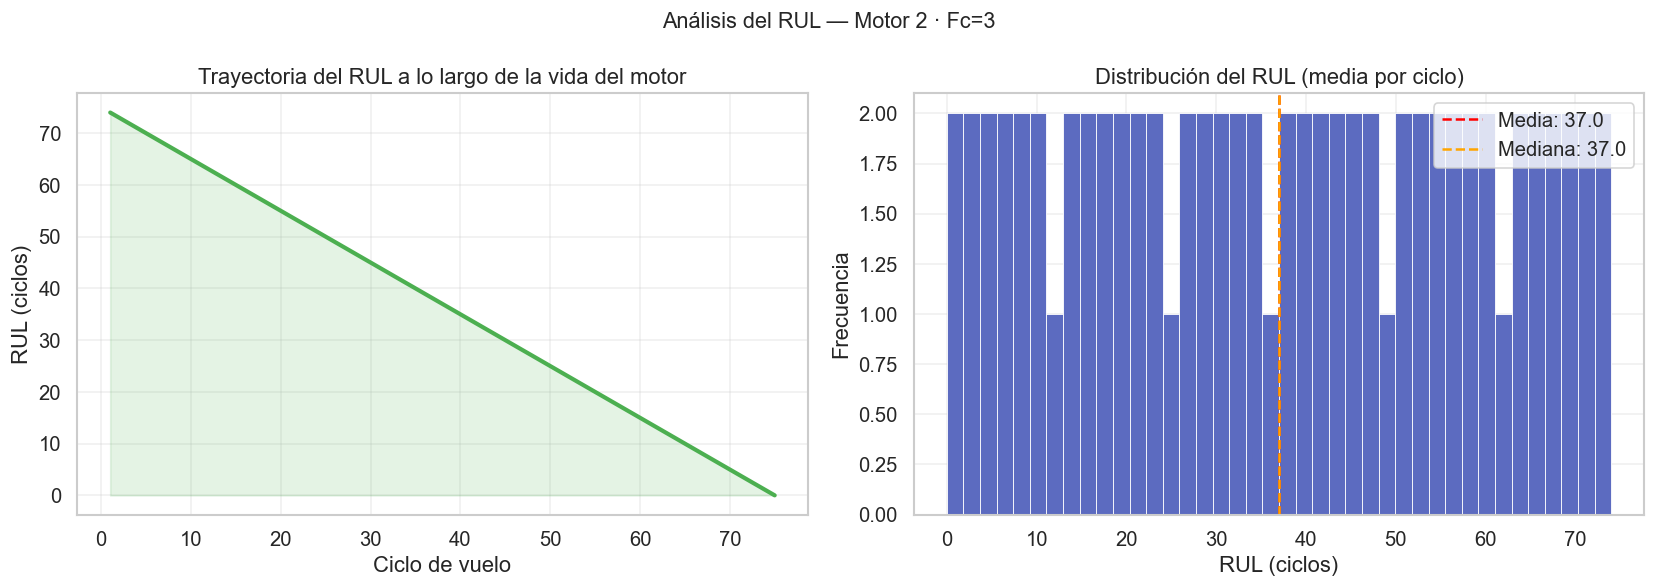

In [8]:
print("\n" + "=" * 60)
print(f"SECCIÓN 4 — ANÁLISIS DEL RUL  (Motor {MOTOR} · Fc={FC})")
print("=" * 60)

rul_cyc = df_dev.groupby('cycle')['RUL'].mean()

print(f"\nEstadísticos del RUL:")
print(f"  Mínimo : {df_dev['RUL'].min():.0f} ciclos")
print(f"  Máximo : {df_dev['RUL'].max():.0f} ciclos")
print(f"  Media  : {df_dev['RUL'].mean():.1f} ciclos")
print(f"  Mediana: {df_dev['RUL'].median():.1f} ciclos")
print(f"  Std    : {df_dev['RUL'].std():.1f} ciclos")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Análisis del RUL — Motor {MOTOR} · Fc={FC}', fontsize=13)

axes[0].plot(rul_cyc.index, rul_cyc.values, color='#4CAF50', lw=2.5)
axes[0].fill_between(rul_cyc.index, rul_cyc.values, alpha=0.15, color='#4CAF50')
axes[0].set_xlabel('Ciclo de vuelo')
axes[0].set_ylabel('RUL (ciclos)')
axes[0].set_title('Trayectoria del RUL a lo largo de la vida del motor')
axes[0].grid(alpha=0.3)

axes[1].hist(rul_cyc.values, bins=40, color='#5C6BC0', edgecolor='white', lw=0.5)
axes[1].axvline(rul_cyc.mean(), color='red', ls='--', lw=1.5,
                label=f'Media: {rul_cyc.mean():.1f}')
axes[1].axvline(rul_cyc.median(), color='orange', ls='--', lw=1.5,
                label=f'Mediana: {rul_cyc.median():.1f}')
axes[1].set_xlabel('RUL (ciclos)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución del RUL (media por ciclo)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

SECCIÓN 5 — DESCRIPTORES DE ESCENARIO W (Motor 2 · Fc=3)

Con el filtro Fc=3 activo, las variables W describen las condiciones de

operación DENTRO de la clase de vuelo largo (>5h). La variabilidad que

vemos aquí refleja las diferencias entre vuelos del mismo tipo, no entre

clases. Esto es útil para entender si la normalización por W sigue siendo

necesaria incluso dentro de una misma clase.


SECCIÓN 5 — ESCENARIO W  (Motor 2 · Fc=3)

[5.1] Estadísticos de variables de escenario:
            mean        std        min         max
alt   18989.1529  8403.2103  3001.0000  35033.0000
Mach      0.5794     0.1184     0.1992      0.7493
TRA      64.9740    17.7632    23.8182     88.7689
T2      481.7596    21.0944   421.3779    525.0432


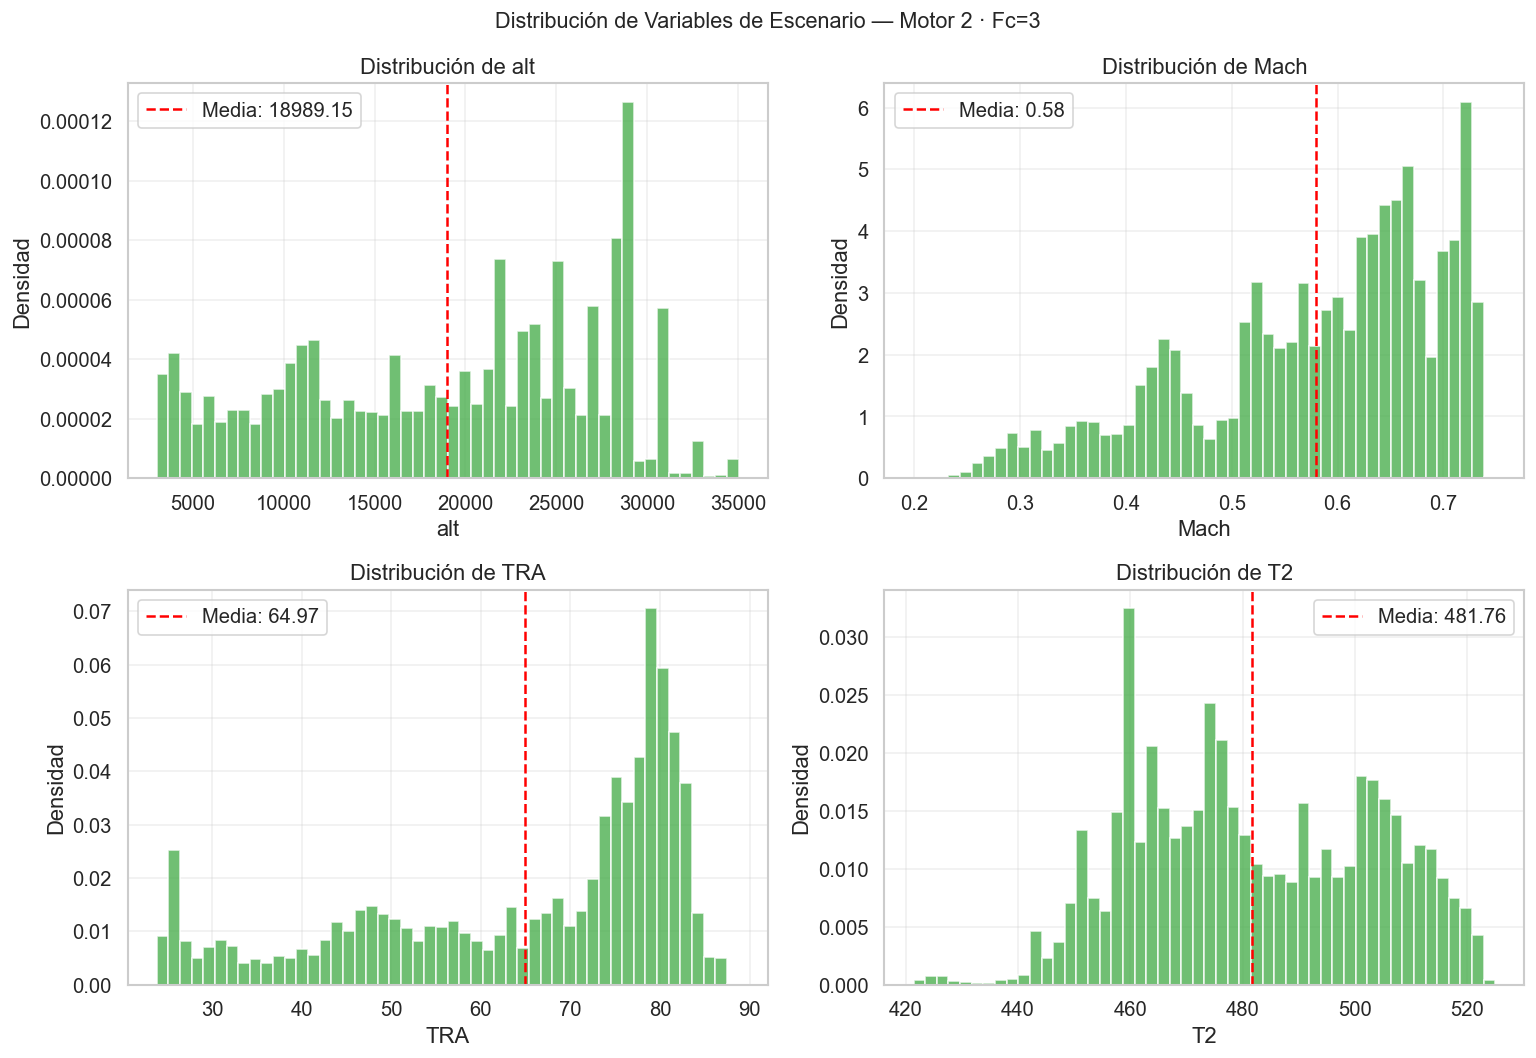

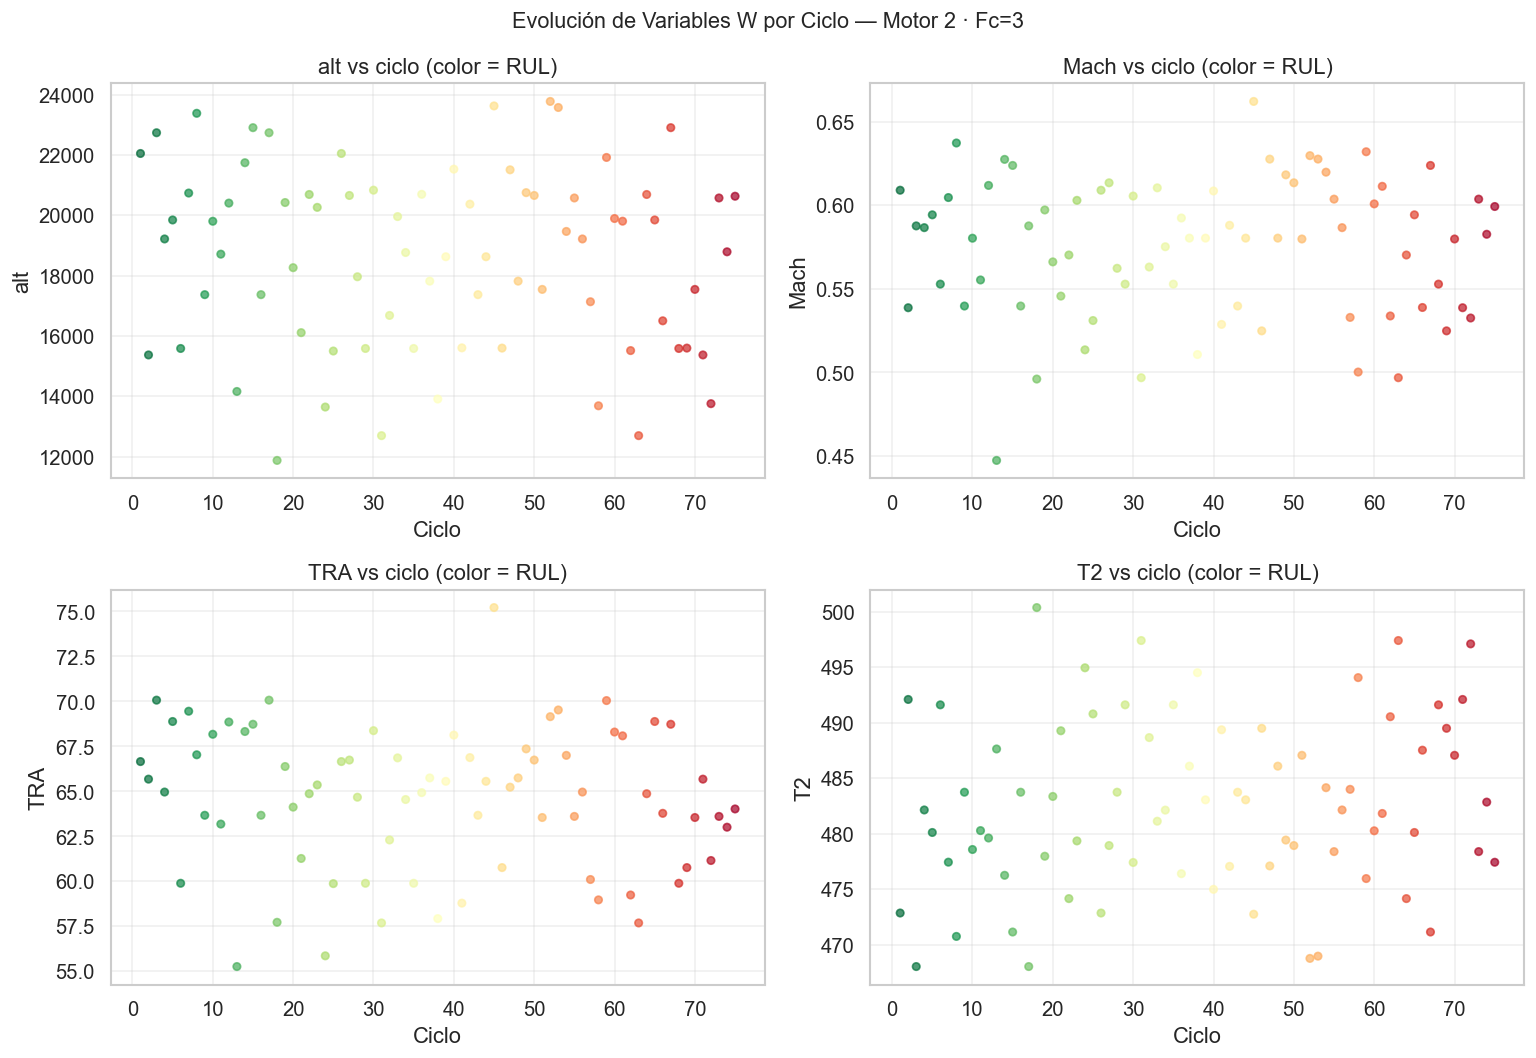

In [9]:
print("\n" + "=" * 60)
print(f"SECCIÓN 5 — ESCENARIO W  (Motor {MOTOR} · Fc={FC})")
print("=" * 60)

print("\n[5.1] Estadísticos de variables de escenario:")
print(df_dev[W_var].describe().T[['mean','std','min','max']].round(4))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f'Distribución de Variables de Escenario — Motor {MOTOR} · Fc={FC}', fontsize=13)
axes = axes.flatten()

for i, var in enumerate(W_var):
    axes[i].hist(df_dev[var], bins=50, color='#4CAF50', edgecolor='white',
                 alpha=0.8, density=True)
    axes[i].axvline(df_dev[var].mean(), color='red', ls='--', lw=1.5,
                    label=f'Media: {df_dev[var].mean():.2f}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Densidad')
    axes[i].set_title(f'Distribución de {var}')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Evolución de W a lo largo de la vida del motor (media por ciclo)
df_cyc = df_dev.groupby('cycle')[W_var + Xs_var + ['RUL']].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f'Evolución de Variables W por Ciclo — Motor {MOTOR} · Fc={FC}', fontsize=13)
axes = axes.flatten()

for i, var in enumerate(W_var):
    axes[i].scatter(df_cyc['cycle'], df_cyc[var],
                    c=df_cyc['RUL'], cmap='RdYlGn', s=20, alpha=0.7)
    axes[i].set_xlabel('Ciclo')
    axes[i].set_ylabel(var)
    axes[i].set_title(f'{var} vs ciclo (color = RUL)')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()


SECCIÓN 6 — ANÁLISIS DE SENSORES X_s (Motor 2 · Fc=3)

Con Fc=3 fijo, las diferencias entre sensores reflejan únicamente el

estado de degradación del motor (y el ruido de medida), sin mezcla

de condiciones de escenario entre clases. Los sensores que muestran

drift sistemático a lo largo de los ciclos son los candidatos naturales

a features predictivos del RUL.


SECCIÓN 6 — SENSORES X_s  (Motor 2 · Fc=3)

[6.1] Estadísticos descriptivos de los sensores:
           mean       std        min        max
T24    563.7346   21.4047   484.1972   631.1130
T30   1324.1729   65.0544  1070.7188  1523.9688
T48   1642.0272  116.0552   955.0565  1986.3234
T50   1117.5267   61.9358   698.4278  1344.8725
P15     11.8263    2.9344     5.9176    20.0660
P2       9.1186    2.4636     4.3732    14.7513
P21     12.0064    2.9790     6.0077    20.3716
P24     14.7091    3.4895     6.9144    25.9546
Ps30   221.6520   56.9598    80.3399   445.5403
P40    225.5078   57.8135    82.1017   452.1810
P50      9.0398    2.7710     4.1293    16.6867
Nf    1986.9005  173.6097  1472.1186  2284.5333
Nc    8218.1106  215.4943  7370.7609  8858.8477
Wf       2.3914    0.7382     0.3424     5.5901


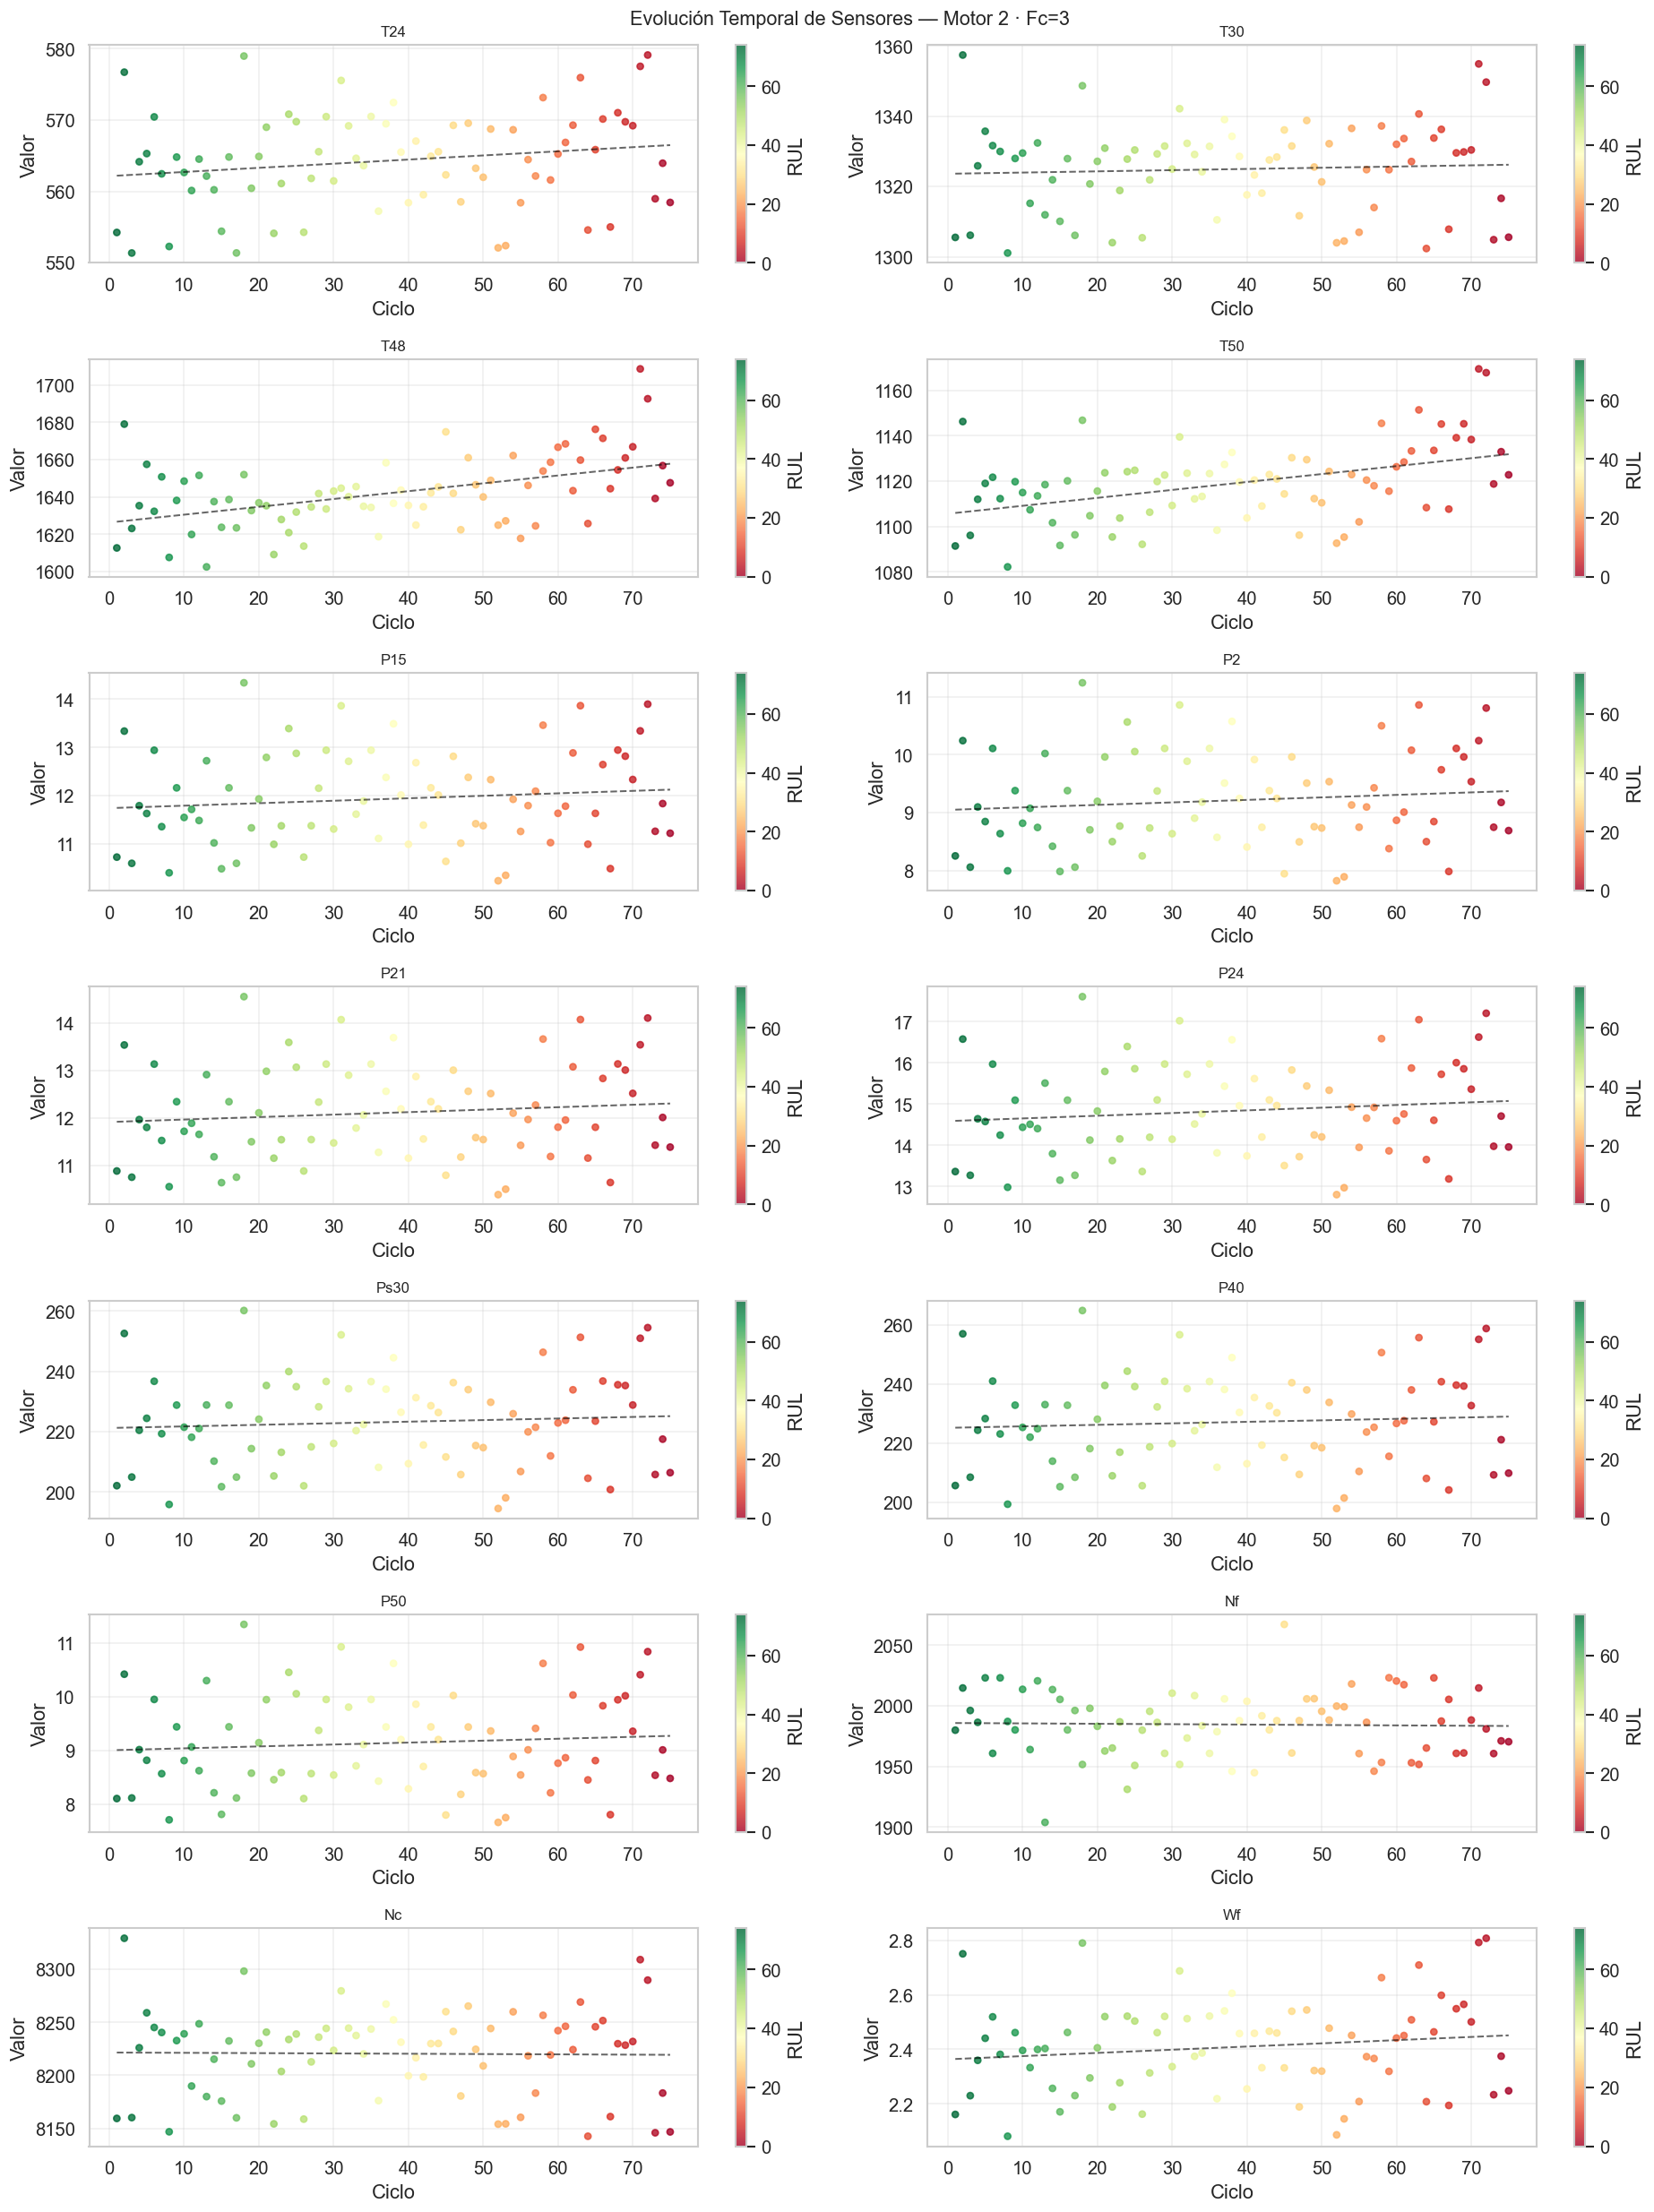

In [10]:

print("\n" + "=" * 60)
print(f"SECCIÓN 6 — SENSORES X_s  (Motor {MOTOR} · Fc={FC})")
print("=" * 60)

print("\n[6.1] Estadísticos descriptivos de los sensores:")
print(df_dev[Xs_var].describe().T[['mean', 'std', 'min', 'max']].round(4))

# Evolución temporal — media por ciclo
df_cyc = df_dev.groupby('cycle')[W_var + Xs_var + ['RUL']].mean().reset_index()

n_sensors = len(Xs_var)
n_cols    = 2
n_rows    = (n_sensors + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
fig.suptitle(f'Evolución Temporal de Sensores — Motor {MOTOR} · Fc={FC}', fontsize=13)
axes = axes.flatten()

for i, sensor in enumerate(Xs_var):
    sc = axes[i].scatter(df_cyc['cycle'], df_cyc[sensor],
                         c=df_cyc['RUL'], cmap='RdYlGn', s=18, alpha=0.8)
    z = np.polyfit(df_cyc['cycle'], df_cyc[sensor], 1)
    xr = np.linspace(df_cyc['cycle'].min(), df_cyc['cycle'].max(), 100)
    axes[i].plot(xr, np.poly1d(z)(xr), 'k--', lw=1.2, alpha=0.6)
    axes[i].set_title(sensor, fontsize=10)
    axes[i].set_xlabel('Ciclo')
    axes[i].set_ylabel('Valor')
    axes[i].grid(alpha=0.3)
    plt.colorbar(sc, ax=axes[i], label='RUL')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


SECCIÓN 7 — DISTRIBUCIÓN DE SENSORES POR FASE DE DEGRADACIÓN

En lugar de comparar por clase de vuelo (solo tenemos Fc=3), dividimos

el ciclo de vida en cuatro fases según el RUL para ver cómo cambia la

distribución de cada sensor conforme el motor se acerca al fallo.


SECCIÓN 7 — DISTRIBUCIÓN POR FASE  (Motor 2 · Fc=3)

[7.1] Umbrales de fase (RUL):
  Sano      : RUL > 56
  Leve      : RUL > 36
  Medio     : RUL > 19
  Crítico   : RUL ≤ 19

[7.2] Muestras por fase:
fase
Sano          254273
Deg. leve     270228
Deg. media    252604
Crítico       271983
Name: count, dtype: int64


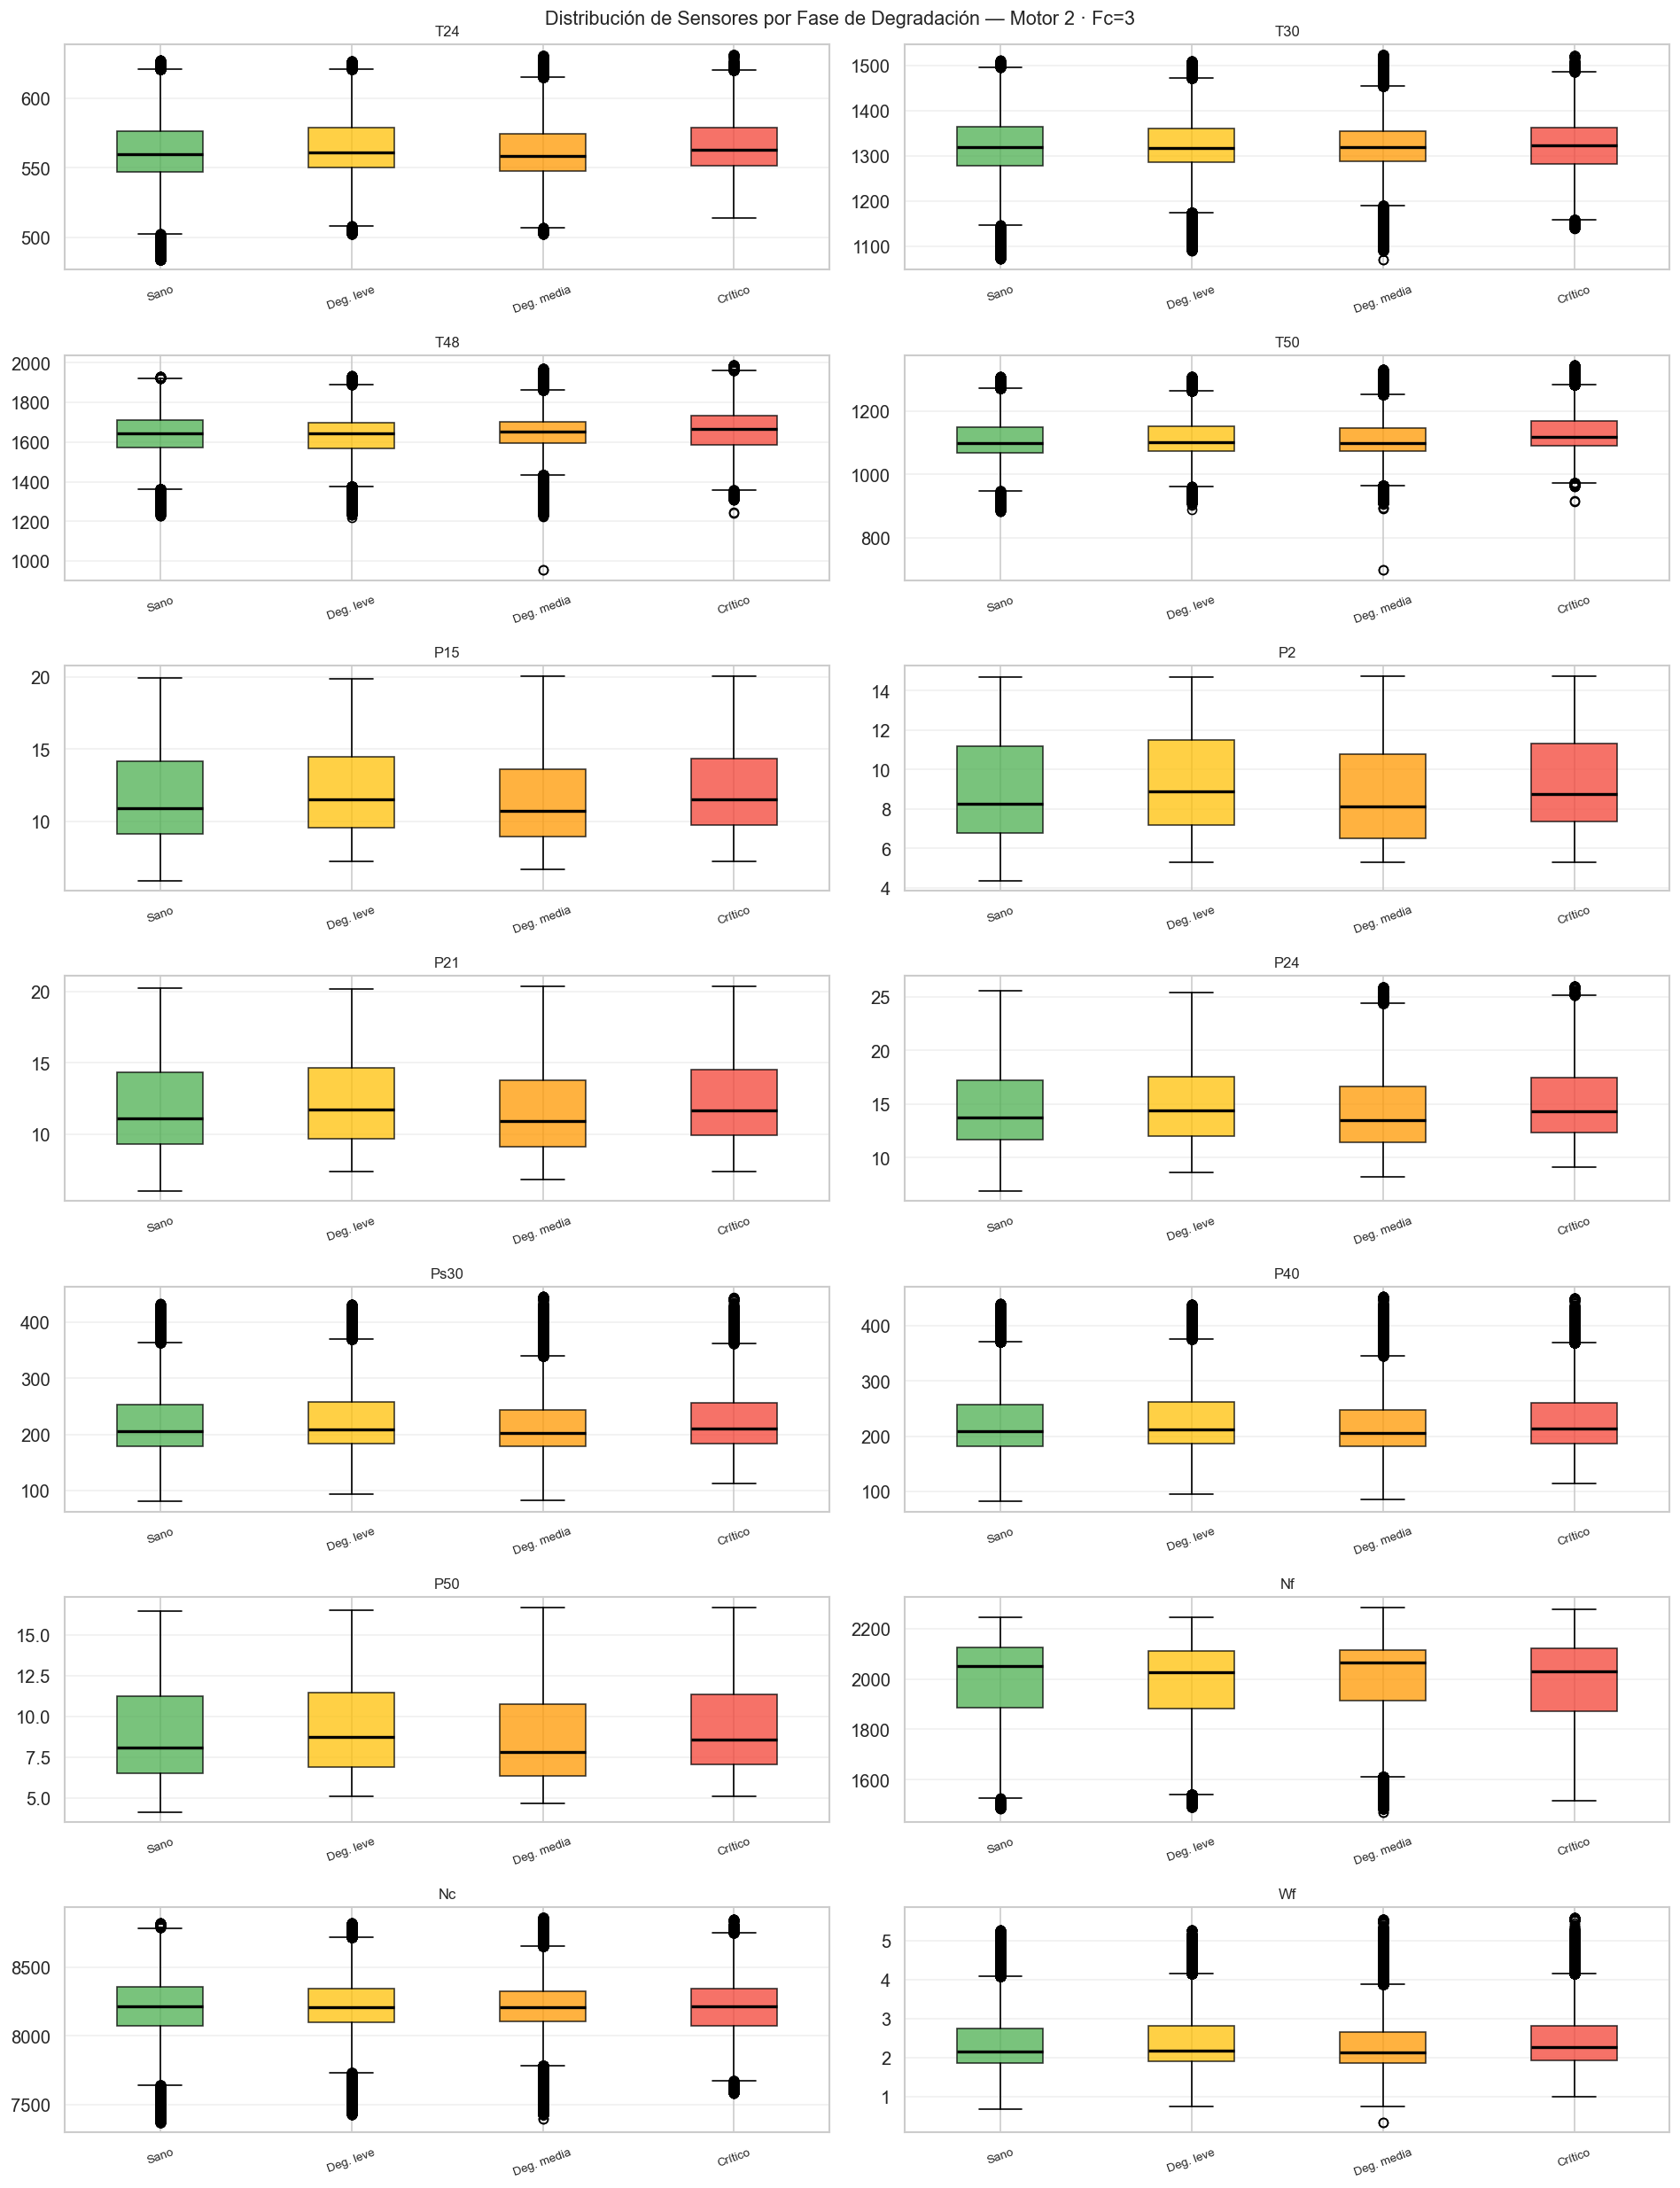

In [11]:
print("\n" + "=" * 60)
print(f"SECCIÓN 7 — DISTRIBUCIÓN POR FASE  (Motor {MOTOR} · Fc={FC})")
print("=" * 60)

# Fases adaptativas por percentil de RUL
p75 = df_dev['RUL'].quantile(0.75)
p50 = df_dev['RUL'].quantile(0.50)
p25 = df_dev['RUL'].quantile(0.25)

def fase(rul):
    if   rul > p75: return '1_Sano'
    elif rul > p50: return '2_Leve'
    elif rul > p25: return '3_Medio'
    else:           return '4_Critico'

df_dev['fase'] = df_dev['RUL'].apply(fase)
orden  = ['1_Sano', '2_Leve', '3_Medio', '4_Critico']
labels = {'1_Sano':'Sano','2_Leve':'Deg. leve','3_Medio':'Deg. media','4_Critico':'Crítico'}
colores_fase = {'1_Sano':'#4CAF50','2_Leve':'#FFC107',
                '3_Medio':'#FF9800','4_Critico':'#F44336'}

print(f"\n[7.1] Umbrales de fase (RUL):")
print(f"  Sano      : RUL > {p75:.0f}")
print(f"  Leve      : RUL > {p50:.0f}")
print(f"  Medio     : RUL > {p25:.0f}")
print(f"  Crítico   : RUL ≤ {p25:.0f}")
print(f"\n[7.2] Muestras por fase:")
print(df_dev['fase'].value_counts().sort_index().rename(labels))

n_sensors = len(Xs_var)
n_cols    = 2
n_rows    = (n_sensors + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
fig.suptitle(f'Distribución de Sensores por Fase de Degradación — Motor {MOTOR} · Fc={FC}',
             fontsize=13)
axes = axes.flatten()

for i, sensor in enumerate(Xs_var):
    data_by_fase = [df_dev[df_dev['fase'] == f][sensor].values for f in orden]
    bp = axes[i].boxplot(data_by_fase,
                         labels=[labels[f] for f in orden],
                         patch_artist=True,
                         medianprops=dict(color='black', lw=2))
    for patch, f in zip(bp['boxes'], orden):
        patch.set_facecolor(colores_fase[f])
        patch.set_alpha(0.75)
    axes[i].set_title(sensor, fontsize=10)
    axes[i].set_xticklabels([labels[f] for f in orden], rotation=20, fontsize=8)
    axes[i].grid(axis='y', alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


SECCIÓN 8 — CORRELACIÓN CON EL RUL (Motor 2 · Fc=3)

Calculamos la correlación de Pearson entre cada sensor/variable W y el RUL.

Con Fc=3 fijo, las correlaciones reflejan relaciones de degradación reales,

no mezcla de escenarios. Un sensor con |r| > 0.7 es un predictor fuerte

del RUL dentro de esta clase de vuelo.


SECCIÓN 8 — CORRELACIÓN CON RUL  (Motor 2 · Fc=3)

[8.1] Correlación de Pearson con RUL:
T50    -0.1156
T48    -0.0740
T24    -0.0517
T2     -0.0474
P24    -0.0345
P2     -0.0330
P21    -0.0323
P15    -0.0323
Wf     -0.0290
P50    -0.0230
Ps30   -0.0143
P40    -0.0134
Mach   -0.0092
T30    -0.0063
Nf      0.0057
Nc      0.0077
TRA     0.0195
alt     0.0267


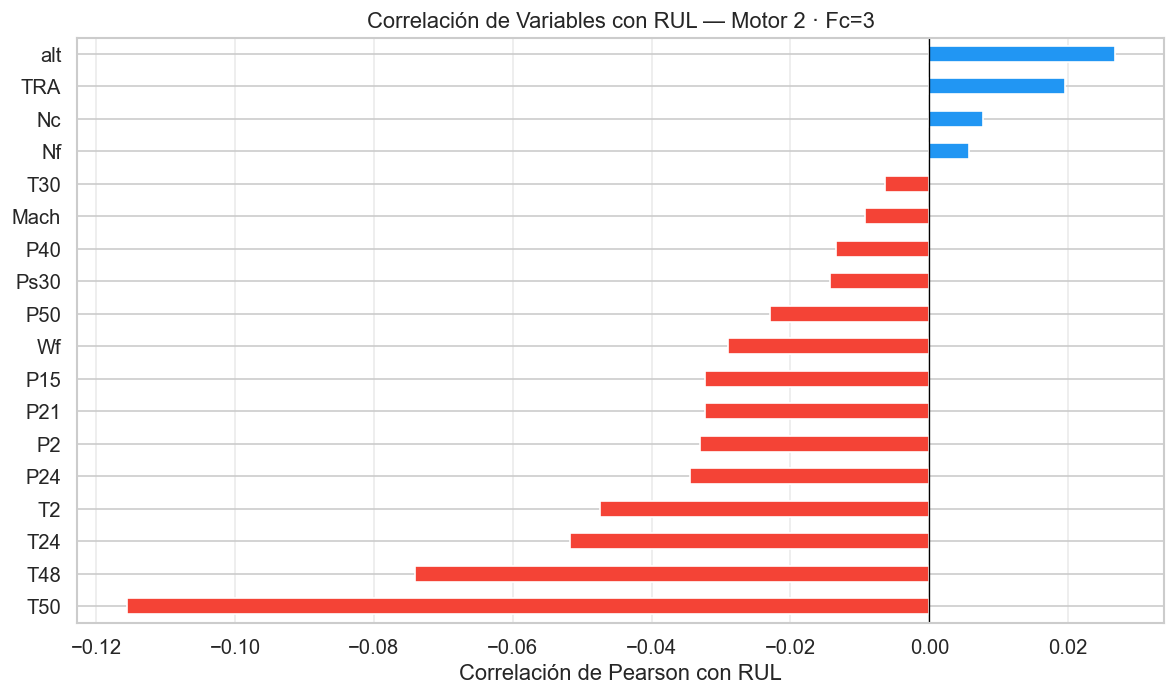

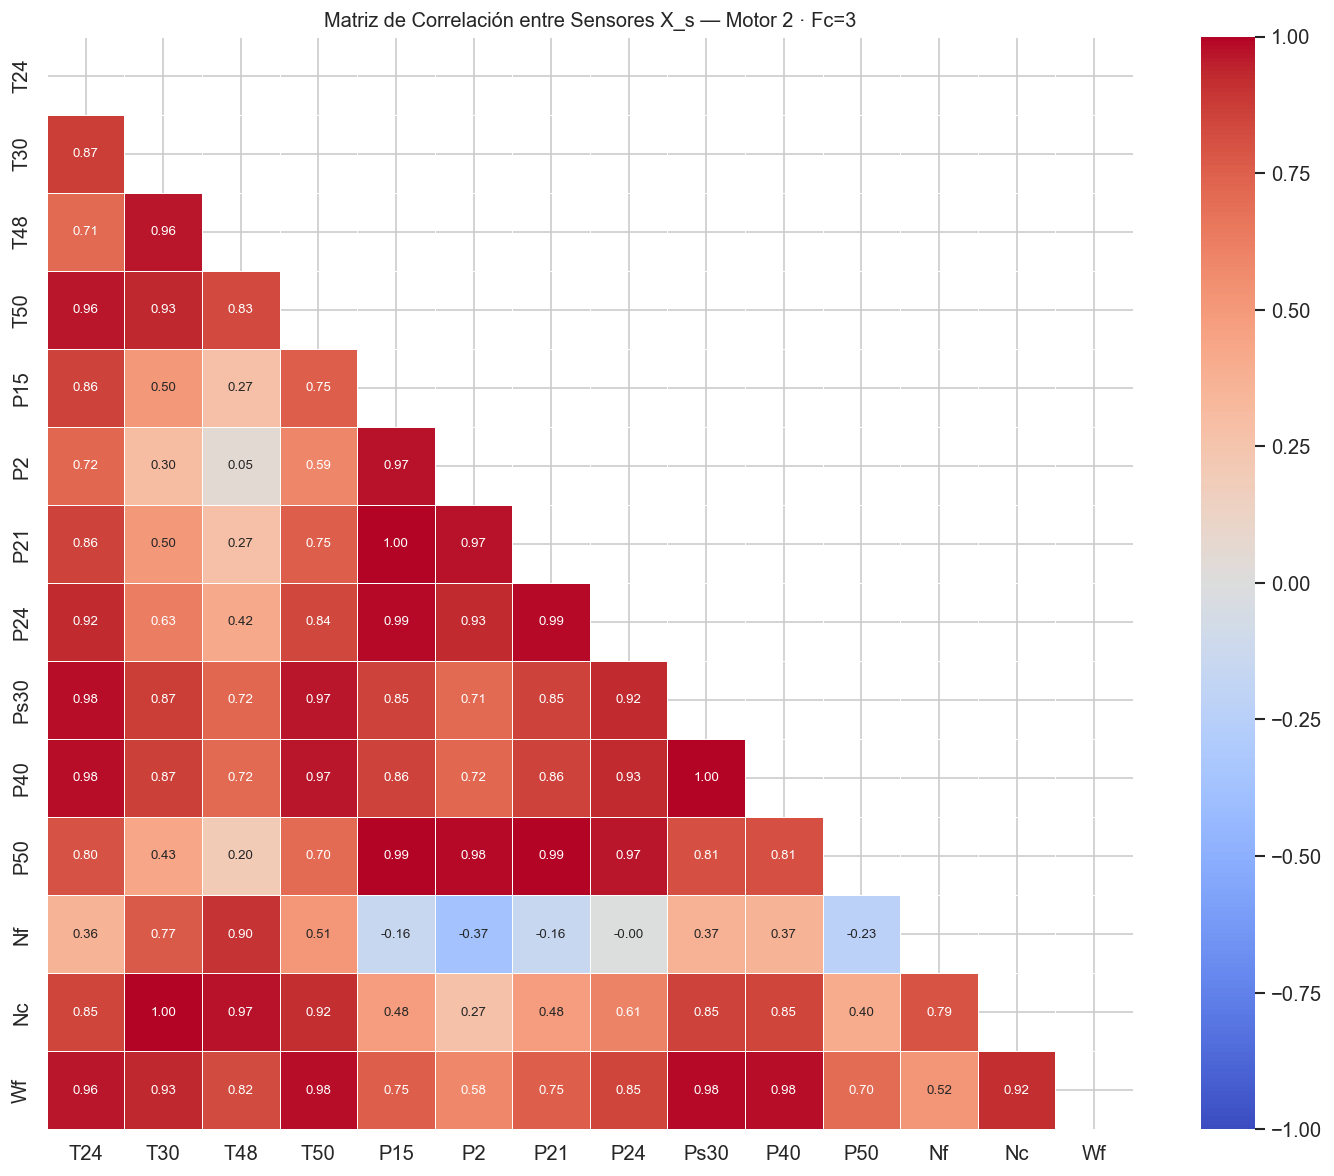

In [12]:
print("\n" + "=" * 60)
print(f"SECCIÓN 8 — CORRELACIÓN CON RUL  (Motor {MOTOR} · Fc={FC})")
print("=" * 60)

# Solo W y X_s — sin hs
feature_cols  = W_var + Xs_var
corr_with_rul = (df_dev[feature_cols + ['RUL']]
                 .corr()['RUL']
                 .drop('RUL')
                 .sort_values())

print("\n[8.1] Correlación de Pearson con RUL:")
print(corr_with_rul.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colors_corr = ['#F44336' if v < 0 else '#2196F3' for v in corr_with_rul.values]
corr_with_rul.plot(kind='barh', ax=ax, color=colors_corr, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Correlación de Pearson con RUL')
ax.set_title(f'Correlación de Variables con RUL — Motor {MOTOR} · Fc={FC}')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

# Matriz de correlación entre sensores
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df_dev[Xs_var].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title(f'Matriz de Correlación entre Sensores X_s — Motor {MOTOR} · Fc={FC}', fontsize=12)
plt.tight_layout()
plt.show()


SECCIÓN 9 — TOP SENSORES VS RUL (Motor 2 · Fc=3)

Visualizamos los scatter de los 6 sensores con mayor |r| respecto al RUL.

Con Fc=3 fijo, los patrones son más limpios que con todos los escenarios

mezclados. Coloreamos por ciclo para ver la trayectoria temporal.


SECCIÓN 9 — TOP SENSORES VS RUL  (Motor 2 · Fc=3)

[9.1] Top 6 sensores más correlacionados con RUL: ['T50', 'T48', 'T24', 'P24', 'P2', 'P21']


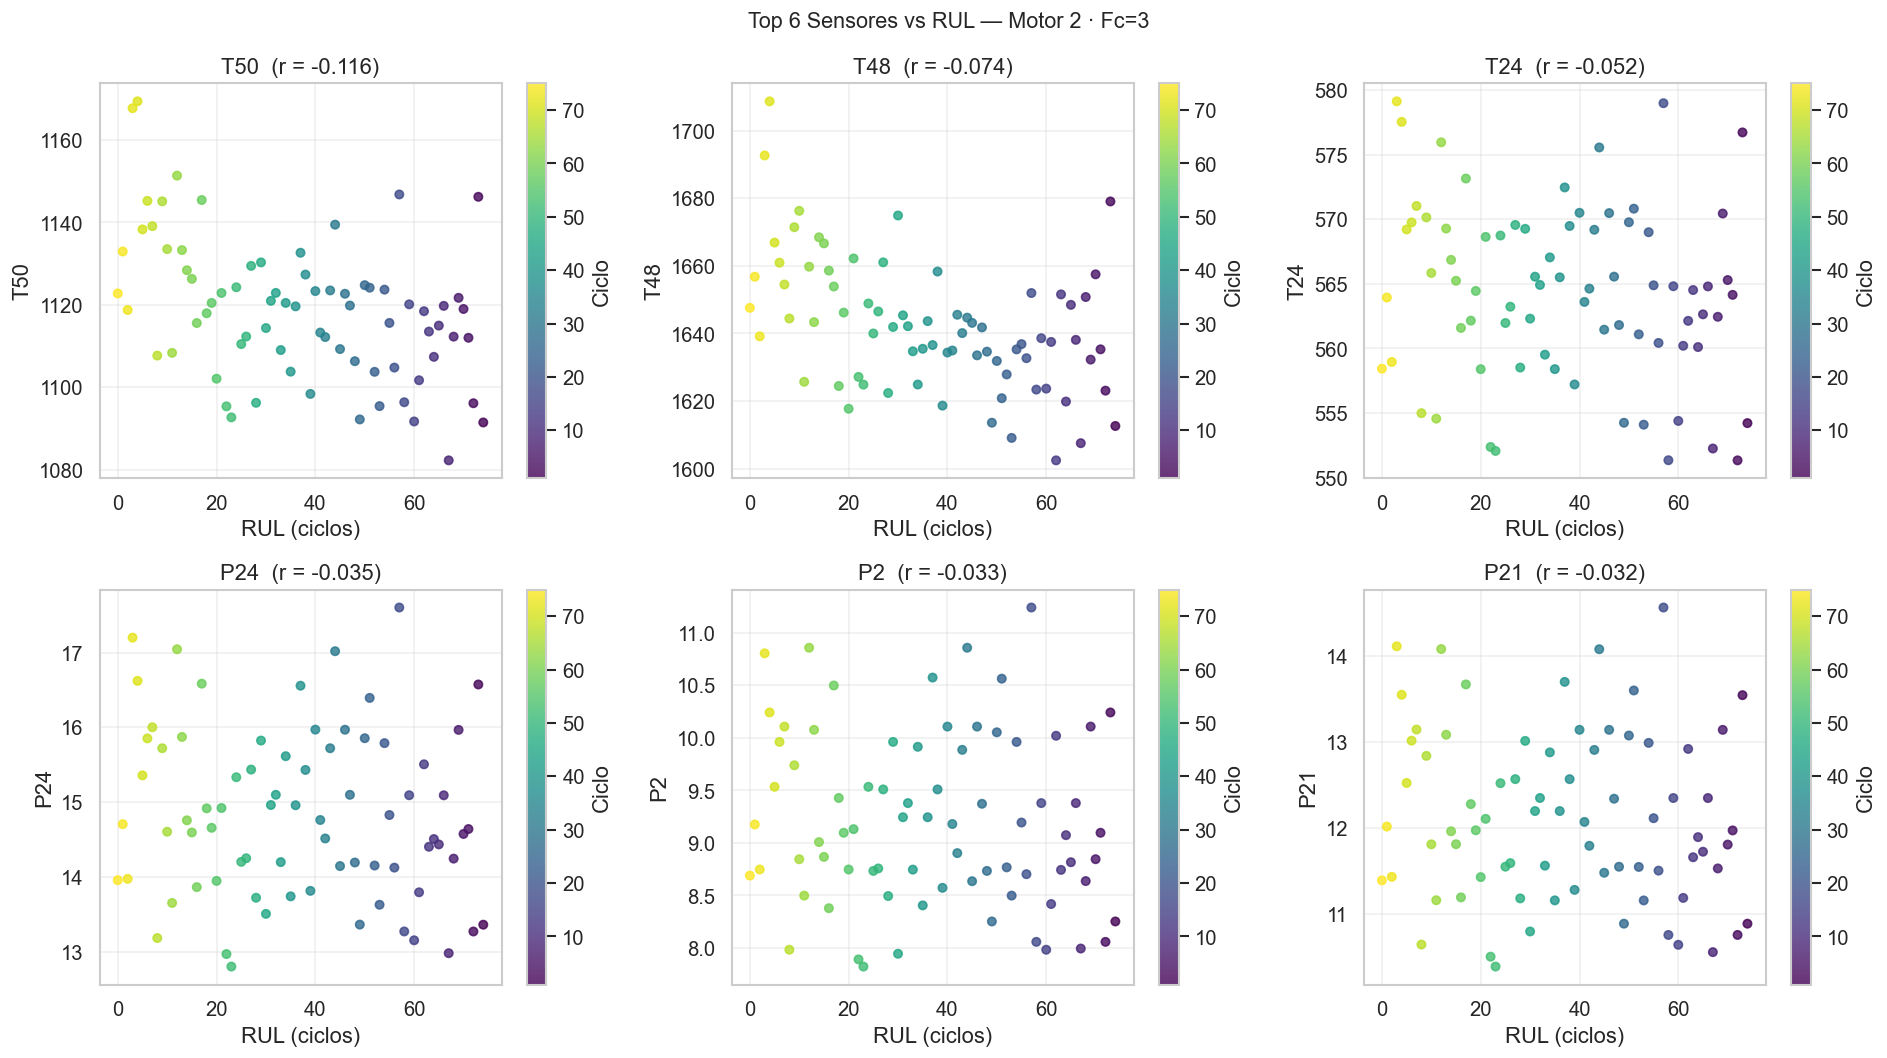

In [13]:
print("\n" + "=" * 60)
print(f"SECCIÓN 9 — TOP SENSORES VS RUL  (Motor {MOTOR} · Fc={FC})")
print("=" * 60)

top_n       = 6
top_sensors = (corr_with_rul.abs()
               .sort_values(ascending=False)
               .index[corr_with_rul.abs().sort_values(ascending=False).index.isin(Xs_var)]
               .tolist()[:top_n])

print(f"\n[9.1] Top {top_n} sensores más correlacionados con RUL: {top_sensors}")

df_cyc = df_dev.groupby('cycle')[Xs_var + W_var + ['RUL']].mean().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f'Top {top_n} Sensores vs RUL — Motor {MOTOR} · Fc={FC}', fontsize=13)
axes = axes.flatten()

for i, sensor in enumerate(top_sensors):
    sc = axes[i].scatter(df_cyc['RUL'], df_cyc[sensor],
                         c=df_cyc['cycle'], cmap='viridis', s=25, alpha=0.8)
    r_val = corr_with_rul[sensor]
    axes[i].set_xlabel('RUL (ciclos)')
    axes[i].set_ylabel(sensor)
    axes[i].set_title(f'{sensor}  (r = {r_val:.3f})')
    axes[i].grid(alpha=0.3)
    plt.colorbar(sc, ax=axes[i], label='Ciclo')

plt.tight_layout()
plt.show()


SECCIÓN 10 — RESUMEN

In [15]:
print("SECCIÓN 10 — RESUMEN DEL EDA")

top3_corr   = corr_with_rul.abs().sort_values(ascending=False).head(3)
low_var_list = list(low_var.index) if len(low_var) > 0 else ['ninguno']

print(f"""
  Dataset  : N-CMAPSS DS01 — Motor {MOTOR} · Fc={FC}
  Modo fallo: Degradación HPT_eff_mod
  ────────────────────────────────────────────────────────
  Observaciones (desarrollo): {len(df_dev):>10,}
  Observaciones (prueba)    : {len(df_test):>10,}
  Ciclos únicos             : {df_dev['cycle'].nunique()}
  Variables                 : {len(feature_cols)} features  (W + X_s)
  RUL rango                 : [{df_dev['RUL'].min():.0f}, {df_dev['RUL'].max():.0f}] ciclos
  Sensores baja varianza    : {low_var_list}
  ────────────────────────────────────────────────────────
  Top 3 sensores más correlacionados con RUL:""")

for var, val in top3_corr.items():
    print(f"    {var:12s}: |r| = {val:.4f}")



SECCIÓN 10 — RESUMEN DEL EDA

  Dataset  : N-CMAPSS DS01 — Motor 2 · Fc=3
  Modo fallo: Degradación HPT_eff_mod
  ────────────────────────────────────────────────────────
  Observaciones (desarrollo):  1,049,088
  Observaciones (prueba)    :          0
  Ciclos únicos             : 75
  Variables                 : 18 features  (W + X_s)
  RUL rango                 : [0, 74] ciclos
  Sensores baja varianza    : ['ninguno']
  ────────────────────────────────────────────────────────
  Top 3 sensores más correlacionados con RUL:
    T50         : |r| = 0.1156
    T48         : |r| = 0.0740
    T24         : |r| = 0.0517


## Sección 11 — Parámetros de Degradación Internos (T)

Los vectores **T** contienen los modificadores de eficiencia y flujo de cada componente del motor. Cada entrada escala la eficiencia o el caudal de un componente respecto a su valor nominal; una reducción sostenida indica degradación irreversible.

| Variable | Componente |
|---|---|
| `fan_eff_mod` / `fan_flow_mod` | Fan |
| `LPC_eff_mod` / `LPC_flow_mod` | Compresor baja presión |
| `HPC_eff_mod` / `HPC_flow_mod` | Compresor alta presión |
| **`HPT_eff_mod`** | **Turbina alta presión — modo de fallo activo** |
| `HPT_flow_mod` | Turbina alta presión (flujo) |
| `LPT_eff_mod` / `LPT_flow_mod` | Turbina baja presión |

El coeficiente de variación (CV = std / |media|) calculado sobre toda la vida del motor muestra que únicamente **`HPT_eff_mod`** presenta variación significativa (CV > 0.001). El resto de parámetros permanece constante a lo largo de todos los ciclos porque DS01 activa un único modo de fallo: la degradación progresiva de la eficiencia de la turbina de alta presión. Incluir las curvas planas en la visualización no aportaría información y diluiría la señal relevante, por lo que el gráfico se limita exclusivamente a `HPT_eff_mod`.


SECCIÓN 11 — PARÁMETROS T  (Motor 2 · Fc=3)

[11.1] Parámetros T activos (CV > 0.001): ['HPT_eff_mod']
        Parámetros planos              : []


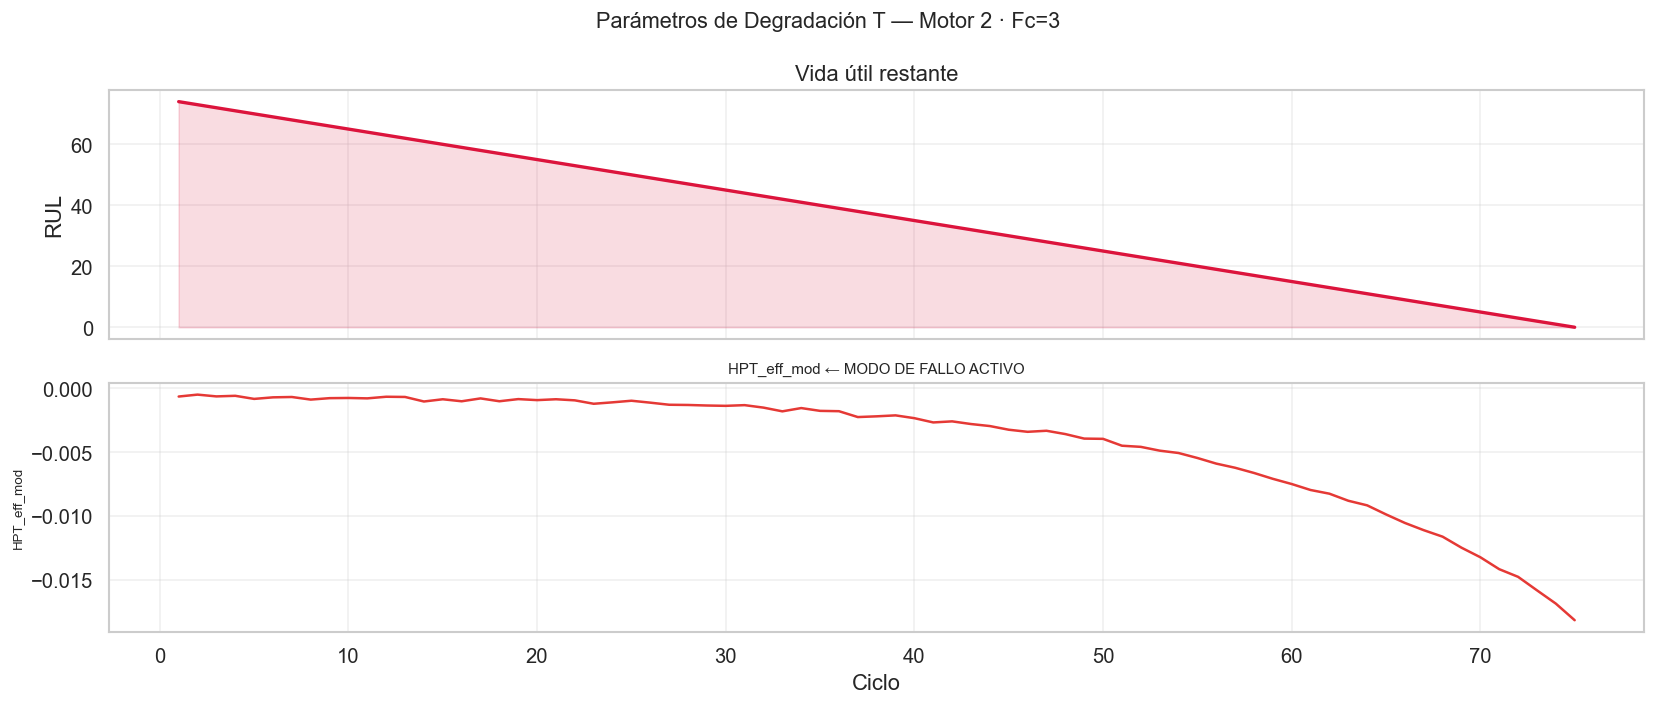


[11.2] Correlación de HPT_eff_mod con cada sensor X_s:
          r  abs_r
T50  -0.136  0.136
T48  -0.085  0.085
T24  -0.051  0.051
P24  -0.039  0.039
P2   -0.037  0.037
P15  -0.037  0.037
P21  -0.037  0.037
Wf   -0.035  0.035
P50  -0.030  0.030
Ps30 -0.018  0.018
P40  -0.016  0.016
Nc    0.013  0.013
Nf    0.009  0.009
T30  -0.004  0.004


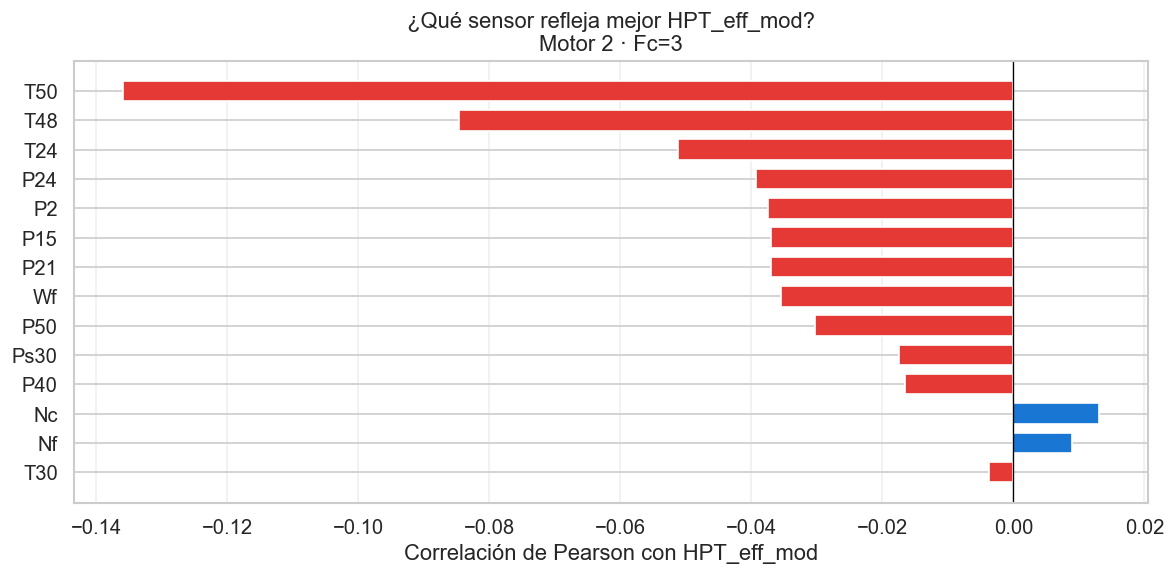

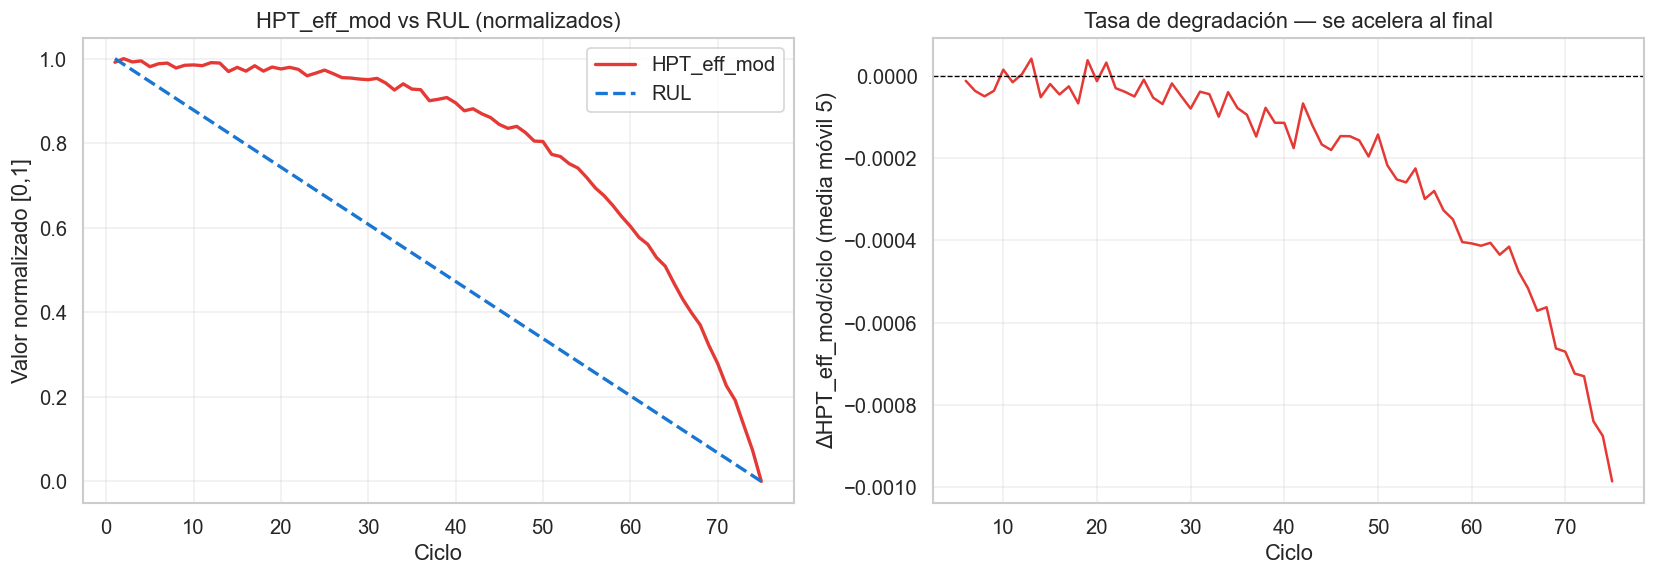

In [14]:
# SECCIÓN 11 — PARÁMETROS DE DEGRADACIÓN INTERNOS (T) — Motor 2 · Fc=3

print("\n" + "=" * 60)
print(f"SECCIÓN 11 — PARÁMETROS T  (Motor {MOTOR} · Fc={FC})")
print("=" * 60)

with h5py.File(FILE_PATH, 'r') as f:
    T_dev_full = np.array(f['T_dev'])
    try:
        T_var = [v.decode() for v in f['T_var'][:]]
    except:
        T_var = [f'T_{i}' for i in range(T_dev_full.shape[1])]

# Alinear con el filtro global usando los índices del df_dev_full original
df_dev_full_idx = df_dev_full[(df_dev_full['unit'] == MOTOR) & (df_dev_full['Fc'] == FC)].index
df_t = pd.DataFrame(T_dev_full[df_dev_full_idx], columns=T_var)
df_t.index = df_dev.index
for col in T_var:
    df_dev[col] = df_t[col].values

t_cv = df_dev[T_var].std() / df_dev[T_var].mean().abs()
t_varying = t_cv[t_cv > 0.001].index.tolist()
t_flat    = t_cv[t_cv <= 0.001].index.tolist()

print(f"\n[11.1] Parámetros T activos (CV > 0.001): {t_varying}")
print(f"        Parámetros planos              : {t_flat}")

df_m2_cyc = df_dev.groupby('cycle')[T_var + ['RUL']].mean().reset_index()

fig, axes = plt.subplots(len(t_varying) + 1, 1,
                         figsize=(14, 3 * (len(t_varying) + 1)), sharex=True)
fig.suptitle(f'Parámetros de Degradación T — Motor {MOTOR} · Fc={FC}', fontsize=13)

axes[0].plot(df_m2_cyc['cycle'], df_m2_cyc['RUL'], color='crimson', lw=2)
axes[0].fill_between(df_m2_cyc['cycle'], df_m2_cyc['RUL'], alpha=0.15, color='crimson')
axes[0].set_ylabel('RUL')
axes[0].set_title('Vida útil restante')
axes[0].grid(alpha=0.3)

for i, col in enumerate(t_varying):
    axes[i+1].plot(df_m2_cyc['cycle'], df_m2_cyc[col], color='#E53935', lw=1.5)
    axes[i+1].set_ylabel(col, fontsize=8)
    axes[i+1].set_title(f'{col} ← MODO DE FALLO ACTIVO', fontsize=9)
    axes[i+1].grid(alpha=0.3)

axes[-1].set_xlabel('Ciclo')
plt.tight_layout()
plt.show()

if t_varying:
    active_T = t_varying[0]
    corr_t_xs = {s: stats.pearsonr(df_dev[active_T], df_dev[s])[0] for s in Xs_var}
    df_corr_t = (pd.DataFrame({'r': corr_t_xs})
                 .assign(abs_r=lambda x: x['r'].abs())
                 .sort_values('abs_r', ascending=False))
    print(f"\n[11.2] Correlación de {active_T} con cada sensor X_s:")
    print(df_corr_t.round(3).to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    colors_b = ['#1976D2' if v > 0 else '#E53935' for v in df_corr_t['r'].values]
    ax.barh(df_corr_t.index[::-1], df_corr_t['r'].values[::-1],
            color=colors_b[::-1], edgecolor='white', height=0.7)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel(f'Correlación de Pearson con {active_T}')
    ax.set_title(f'¿Qué sensor refleja mejor HPT_eff_mod?\nMotor {MOTOR} · Fc={FC}')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    norm01 = lambda s: (s - s.min()) / (s.max() - s.min() + 1e-12)
    axes[0].plot(df_m2_cyc['cycle'], norm01(df_m2_cyc[active_T]),
                 color='#E53935', lw=2, label=active_T)
    axes[0].plot(df_m2_cyc['cycle'], norm01(df_m2_cyc['RUL']),
                 color='#1976D2', lw=2, ls='--', label='RUL')
    axes[0].set_xlabel('Ciclo')
    axes[0].set_ylabel('Valor normalizado [0,1]')
    axes[0].set_title(f'{active_T} vs RUL (normalizados)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    delta = df_m2_cyc[active_T].diff()
    axes[1].plot(df_m2_cyc['cycle'], delta.rolling(5).mean(),
                 color='#E53935', lw=1.5)
    axes[1].axhline(0, color='black', lw=0.8, ls='--')
    axes[1].set_xlabel('Ciclo')
    axes[1].set_ylabel(f'Δ{active_T}/ciclo (media móvil 5)')
    axes[1].set_title('Tasa de degradación — se acelera al final')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## Sección 12 — Correlación W × X_s (Motor 2 · Fc=3)

Analizamos cuánto explican las condiciones de operación (W) las lecturas de los sensores.
Incluso dentro de Fc=3, la altitud, el Mach y la TRA varían entre vuelos y pueden
enmascarar la señal de degradación en los sensores si no se controla su efecto.



SECCIÓN 12 — CORRELACIÓN W × X_s  (Motor 2 · Fc=3)


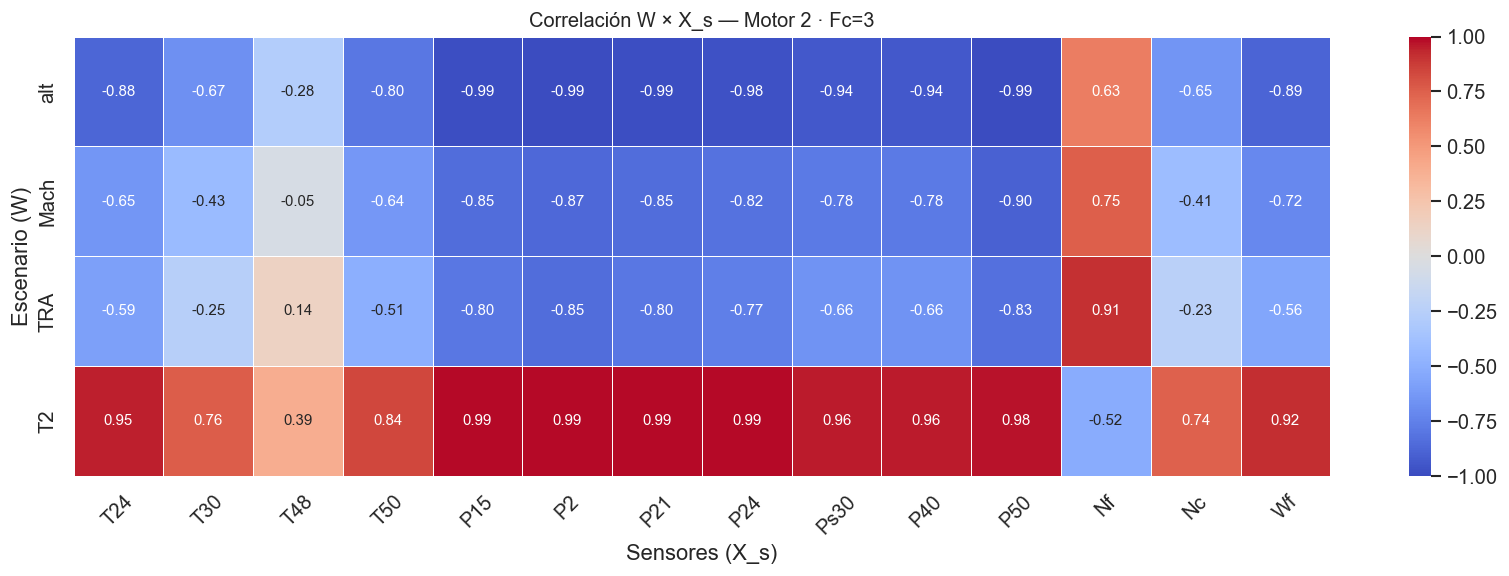


[12.1] Top 10 pares W × sensor por |r|:
W_var sensor         r    abs_r
  alt    P50 -0.993734 0.993734
  alt     P2 -0.992548 0.992548
   T2    P15  0.991235 0.991235
   T2    P21  0.991235 0.991235
   T2     P2  0.990386 0.990386
   T2    P24  0.989099 0.989099
  alt    P15 -0.986059 0.986059
  alt    P21 -0.986059 0.986059
  alt    P24 -0.975423 0.975423
   T2    P50  0.975071 0.975071


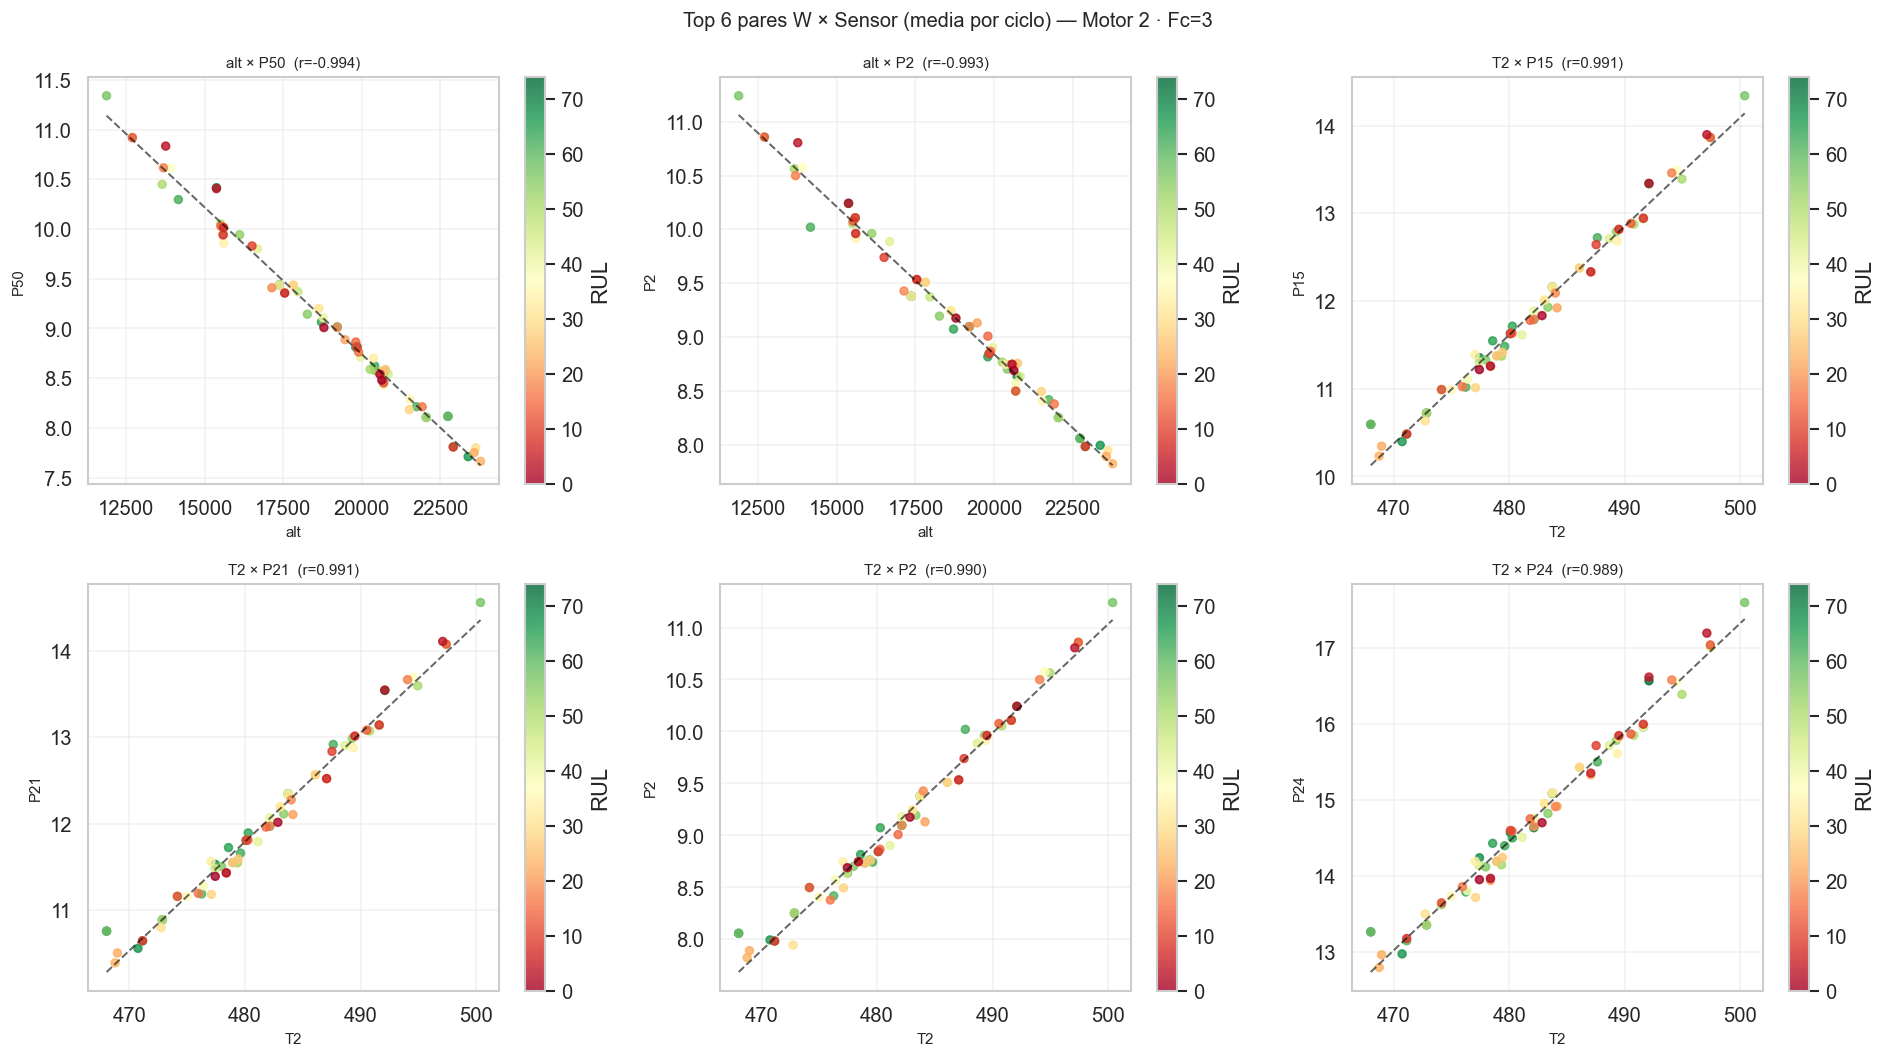

In [15]:
# SECCIÓN 12 — CORRELACIÓN W × X_s  (Motor 2 · Fc=3)

print("\n" + "=" * 60)
print(f"SECCIÓN 12 — CORRELACIÓN W × X_s  (Motor {MOTOR} · Fc={FC})")
print("=" * 60)

df_cyc = df_dev.groupby('cycle')[W_var + Xs_var + ['RUL']].mean().reset_index()
corr_w_xs = df_cyc[W_var + Xs_var].corr().loc[W_var, Xs_var]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(corr_w_xs, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax)
ax.set_title(f'Correlación W × X_s — Motor {MOTOR} · Fc={FC}', fontsize=12)
ax.set_xlabel('Sensores (X_s)')
ax.set_ylabel('Escenario (W)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

pairs_wx = (corr_w_xs.stack().reset_index()
            .rename(columns={'level_0':'W_var','level_1':'sensor',0:'r'})
            .assign(abs_r=lambda x: x['r'].abs())
            .sort_values('abs_r', ascending=False).reset_index(drop=True))

print("\n[12.1] Top 10 pares W × sensor por |r|:")
print(pairs_wx.head(10).to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f'Top 6 pares W × Sensor (media por ciclo) — Motor {MOTOR} · Fc={FC}', fontsize=12)
axes = axes.flatten()

for i, row in pairs_wx.head(6).iterrows():
    w, sensor, r = row['W_var'], row['sensor'], row['r']
    sc = axes[i].scatter(df_cyc[w], df_cyc[sensor],
                         c=df_cyc['RUL'], cmap='RdYlGn', s=22, alpha=0.8)
    z  = np.polyfit(df_cyc[w], df_cyc[sensor], 1)
    xr = np.linspace(df_cyc[w].min(), df_cyc[w].max(), 100)
    axes[i].plot(xr, np.poly1d(z)(xr), 'k--', lw=1.2, alpha=0.6)
    axes[i].set_xlabel(w, fontsize=9)
    axes[i].set_ylabel(sensor, fontsize=9)
    axes[i].set_title(f'{w} × {sensor}  (r={r:.3f})', fontsize=9)
    axes[i].grid(alpha=0.25)
    plt.colorbar(sc, ax=axes[i], label='RUL')

plt.tight_layout()
plt.show()


## Sección 13 — PCA de Sensores (Motor 2 · Fc=3)

Reducción de dimensionalidad para comprobar si la degradación se concentra en pocas
componentes latentes. Con Fc=3 fijo el PCA es más interpretable porque no hay
varianza espuria de escenario que infle las primeras componentes.



SECCIÓN 13 — PCA  (Motor 2 · Fc=3)

[13.1] Varianza explicada por componente:
  PC1:  81.7%  (acum:  81.7%)  ████████████████████████████████████████
  PC2:  15.3%  (acum:  97.0%)  ███████
  PC3:   2.7%  (acum:  99.6%)  █
  PC4:   0.3%  (acum:  99.9%)  
  PC5:   0.1%  (acum: 100.0%)  
  PC6:   0.0%  (acum: 100.0%)  
  PC7:   0.0%  (acum: 100.0%)  
  PC8:   0.0%  (acum: 100.0%)  


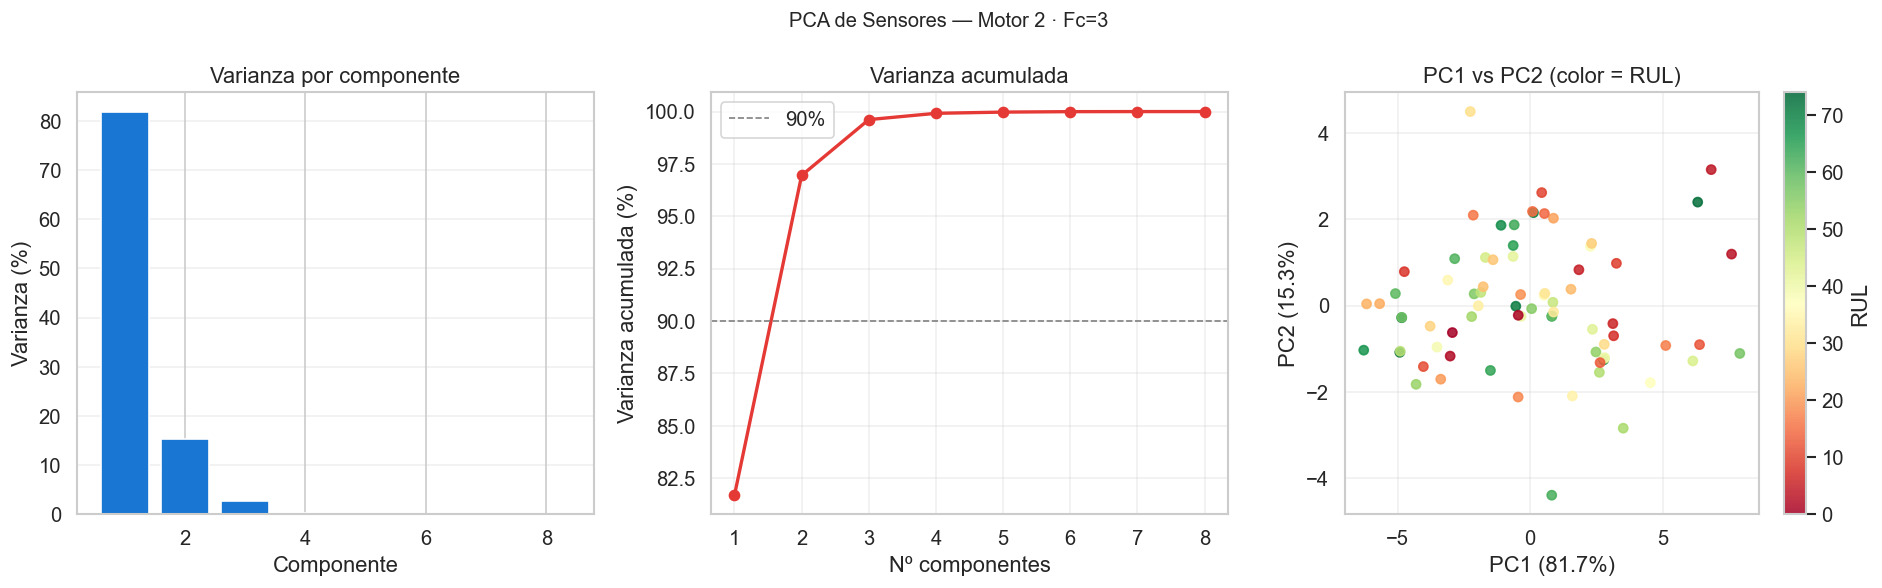

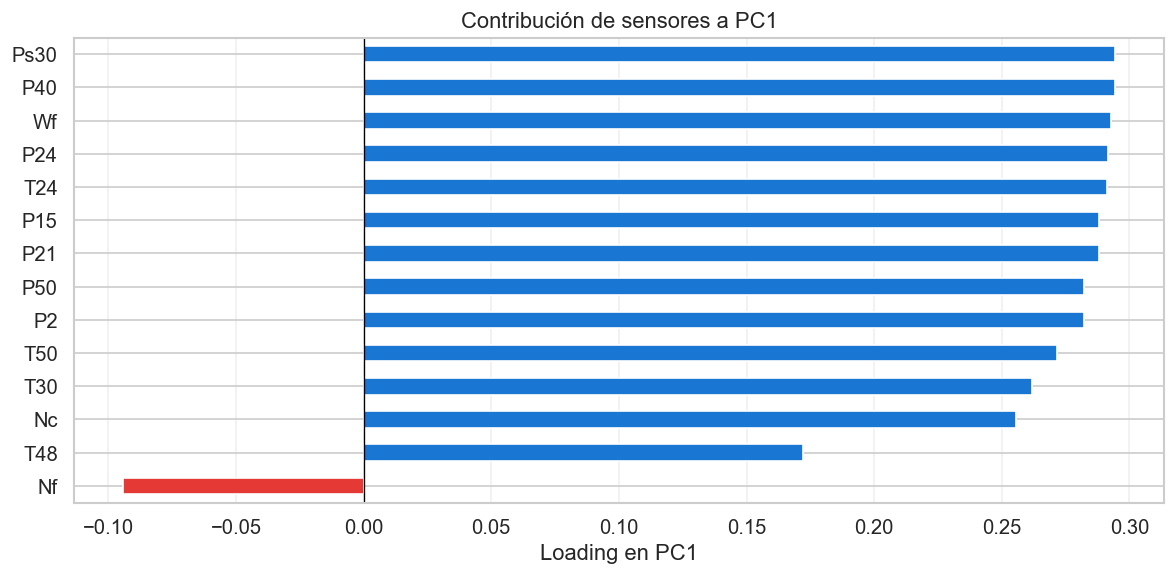


[13.2] Correlación PC1 con RUL: r = -0.1527


In [16]:
# SECCIÓN 13 — PCA DE SENSORES  (Motor 2 · Fc=3)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("\n" + "=" * 60)
print(f"SECCIÓN 13 — PCA  (Motor {MOTOR} · Fc={FC})")
print("=" * 60)

df_cyc = df_dev.groupby('cycle')[Xs_var + ['RUL']].mean().reset_index()

scaler = StandardScaler()
X_sc   = scaler.fit_transform(df_cyc[Xs_var].values)
pca    = PCA(n_components=min(len(Xs_var), 8))
X_pca  = pca.fit_transform(X_sc)

print("\n[13.1] Varianza explicada por componente:")
for i, (ev, cev) in enumerate(zip(pca.explained_variance_ratio_,
                                   np.cumsum(pca.explained_variance_ratio_))):
    print(f"  PC{i+1}: {ev*100:5.1f}%  (acum: {cev*100:5.1f}%)  {'█'*int(ev*50)}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'PCA de Sensores — Motor {MOTOR} · Fc={FC}', fontsize=12)

axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1),
            pca.explained_variance_ratio_*100, color='#1976D2', edgecolor='white')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Varianza (%)')
axes[0].set_title('Varianza por componente')
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(range(1, len(pca.explained_variance_ratio_)+1),
             np.cumsum(pca.explained_variance_ratio_)*100, 'o-', color='#E53935', lw=2)
axes[1].axhline(90, color='gray', ls='--', lw=1, label='90%')
axes[1].set_xlabel('Nº componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada')
axes[1].legend()
axes[1].grid(alpha=0.3)

sc = axes[2].scatter(X_pca[:,0], X_pca[:,1], c=df_cyc['RUL'],
                     cmap='RdYlGn', s=30, alpha=0.85)
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[2].set_title('PC1 vs PC2 (color = RUL)')
plt.colorbar(sc, ax=axes[2], label='RUL')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

loadings = pd.DataFrame(pca.components_.T, index=Xs_var,
                         columns=[f'PC{i+1}' for i in range(pca.n_components_)])
fig, ax = plt.subplots(figsize=(10, 5))
loadings['PC1'].sort_values().plot(
    kind='barh', ax=ax,
    color=['#E53935' if v < 0 else '#1976D2' for v in loadings['PC1'].sort_values()],
    edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Loading en PC1')
ax.set_title('Contribución de sensores a PC1')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

r_pc1, _ = stats.pearsonr(X_pca[:,0], df_cyc['RUL'].values)
print(f"\n[13.2] Correlación PC1 con RUL: r = {r_pc1:.4f}")


## Sección 14 — Cadena Causal: HPT_eff_mod → Sensores

Usamos **correlación cruzada con lag** para determinar qué sensores anticipan,
siguen simultáneamente o reaccionan de forma retardada a la degradación de la HPT.

- **lag < 0** → el sensor anticipa la caída de HPT_eff_mod (*centinela*)
- **lag = 0** → reacción simultánea (*proxy directo*)
- **lag > 0** → efecto retardado (*confirmación tardía*)



SECCIÓN 14 — CADENA CAUSAL  (Motor 2 · Fc=3)
[14.0] Parámetro de degradación activo: HPT_eff_mod

[14.1] Lag óptimo por sensor:
  Sensor            | Lag  | r      | Tipo
  -------------------------------------------------------
  T48               |  -3  | -0.587 | Centinela (lag<0)
  T50               |  -3  | -0.553 | Centinela (lag<0)
  Wf                |  -3  | -0.302 | Centinela (lag<0)
  T24               |  -3  | -0.288 | Centinela (lag<0)
  P24               |  -3  | -0.230 | Centinela (lag<0)
  T30               |  -3  | -0.215 | Centinela (lag<0)
  P21               |  -3  | -0.212 | Centinela (lag<0)
  P15               |  -3  | -0.212 | Centinela (lag<0)
  Ps30              |  -3  | -0.211 | Centinela (lag<0)
  P40               |  -3  | -0.207 | Centinela (lag<0)
  P2                |  -3  | -0.198 | Centinela (lag<0)
  P50               |  -3  | -0.191 | Centinela (lag<0)
  Nc                |  -3  | -0.145 | Centinela (lag<0)
  Nf                | -14  | -0.144 | Cent

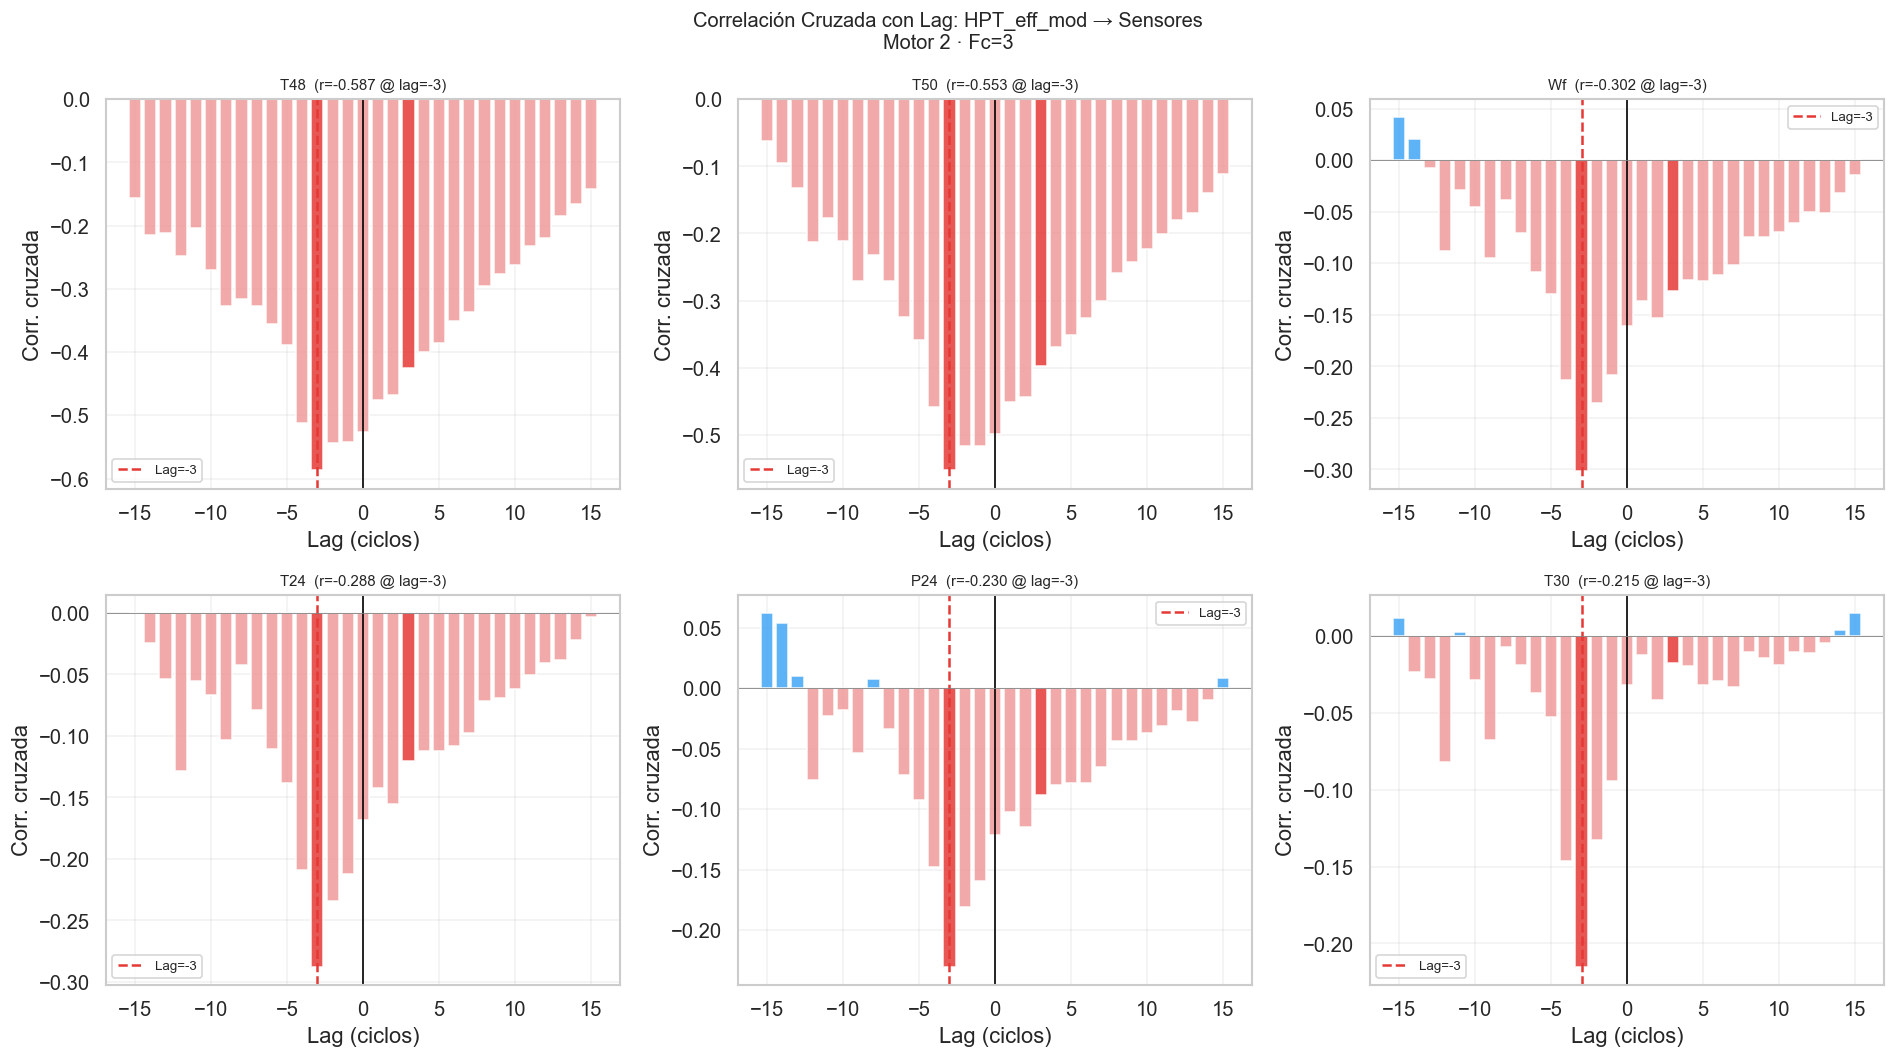

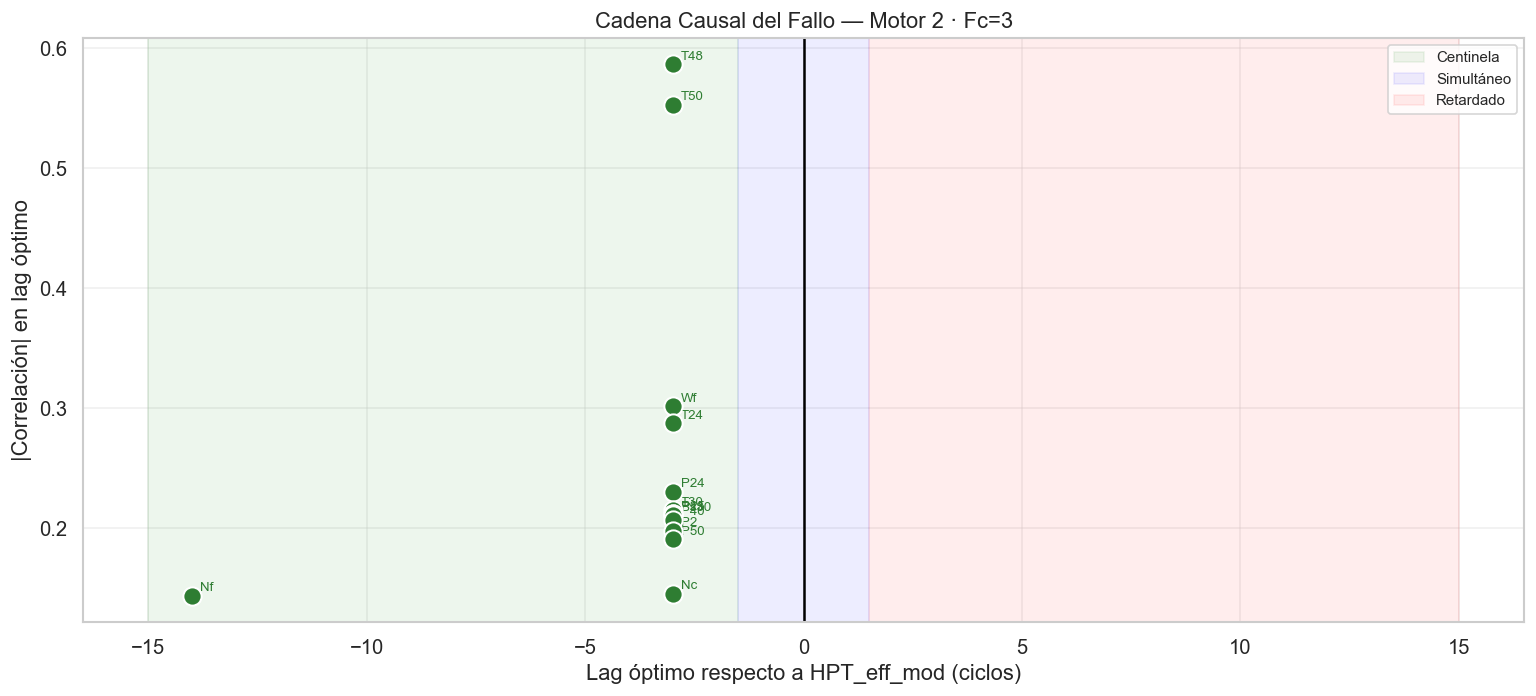

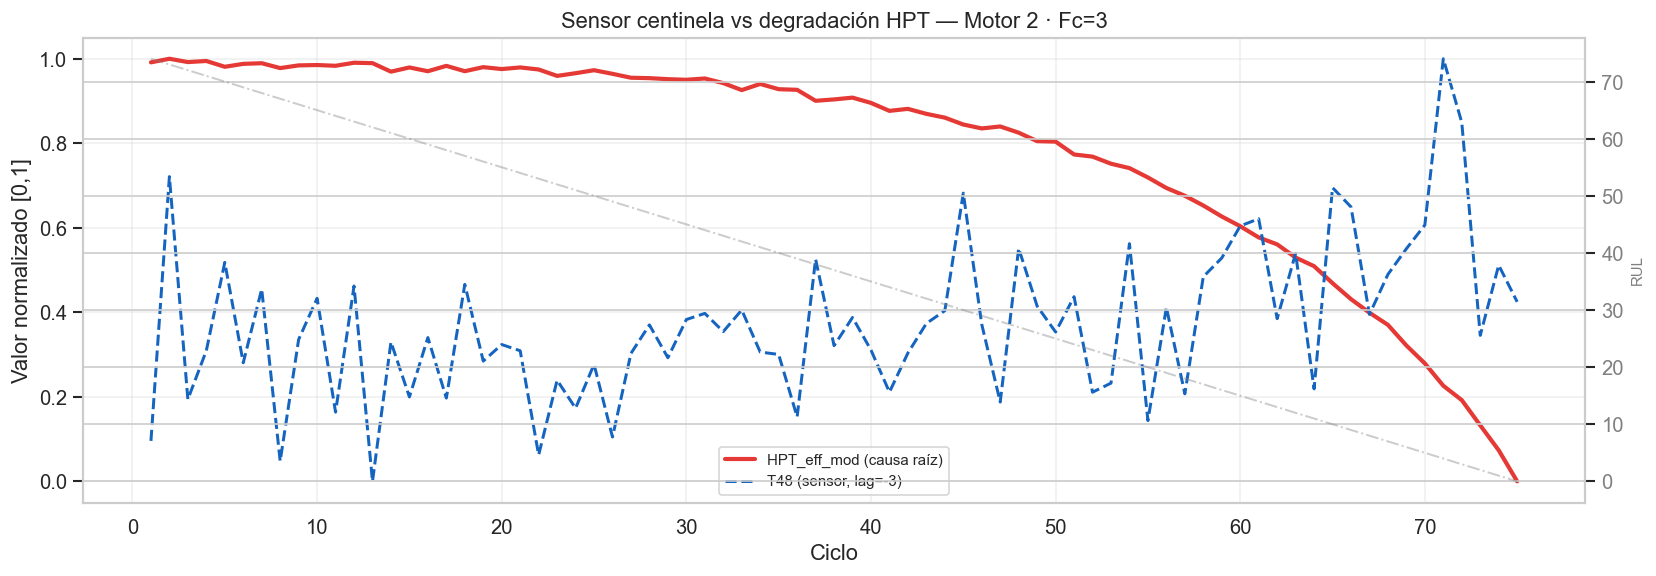


[14.2] Resumen cadena causal:
  Centinela (lag<0):
    · T48              lag= -3  r=-0.587
    · T50              lag= -3  r=-0.553
    · Wf               lag= -3  r=-0.302
    · T24              lag= -3  r=-0.288
    · P24              lag= -3  r=-0.230
    · T30              lag= -3  r=-0.215
    · P21              lag= -3  r=-0.212
    · P15              lag= -3  r=-0.212
    · Ps30             lag= -3  r=-0.211
    · P40              lag= -3  r=-0.207
    · P2               lag= -3  r=-0.198
    · P50              lag= -3  r=-0.191
    · Nc               lag= -3  r=-0.145
    · Nf               lag=-14  r=-0.144



In [17]:
# SECCIÓN 14 — CADENA CAUSAL HPT_eff_mod → SENSORES  (Motor 2 · Fc=3)

from scipy.signal import correlate

print("\n" + "=" * 60)
print(f"SECCIÓN 14 — CADENA CAUSAL  (Motor {MOTOR} · Fc={FC})")
print("=" * 60)

df_m2_cyc = df_dev.groupby('cycle')[Xs_var + T_var + ['RUL']].mean().reset_index()

t_cv_chk = df_m2_cyc[T_var].std() / df_m2_cyc[T_var].mean().abs()
active_T  = t_cv_chk.idxmax()
print(f"[14.0] Parámetro de degradación activo: {active_T}")

MAX_LAG    = 15
hpt_s      = df_m2_cyc[active_T].values
hpt_norm   = (hpt_s - hpt_s.mean()) / hpt_s.std()

lag_results = {}
for sensor in Xs_var:
    s      = df_m2_cyc[sensor].values
    s_norm = (s - s.mean()) / (s.std() + 1e-12)
    full_c = correlate(s_norm, hpt_norm, mode='full') / len(hpt_norm)
    lags   = np.arange(-(len(hpt_norm)-1), len(hpt_norm))
    mask   = (lags >= -MAX_LAG) & (lags <= MAX_LAG)
    lv, cv = lags[mask], full_c[mask]
    best   = np.argmax(np.abs(cv))
    lag_results[sensor] = {
        'best_lag': int(lv[best]), 'best_corr': float(cv[best]),
        'abs_corr': float(np.abs(cv[best])), 'lag_vals': lv, 'corr_vals': cv
    }

df_lags = (pd.DataFrame({s: {'best_lag': v['best_lag'],
                              'best_corr': v['best_corr'],
                              'abs_corr': v['abs_corr']}
                         for s, v in lag_results.items()})
           .T.sort_values('abs_corr', ascending=False)
           .reset_index().rename(columns={'index': 'sensor'}))

df_lags['tipo'] = df_lags['best_lag'].apply(
    lambda l: 'Centinela (lag<0)' if l < -1 else
              ('Simultáneo' if abs(l) <= 1 else 'Retardado (lag>0)'))

print("\n[14.1] Lag óptimo por sensor:")
print(f"  {'Sensor':17s} | Lag  | r      | Tipo")
print("  " + "-"*55)
for _, row in df_lags.iterrows():
    print(f"  {row['sensor']:17s} | {int(row['best_lag']):+3d}  | "
          f"{row['best_corr']:+.3f} | {row['tipo']}")

# Correlograma top 6
top6 = df_lags.head(6)['sensor'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f'Correlación Cruzada con Lag: {active_T} → Sensores\nMotor {MOTOR} · Fc={FC}',
             fontsize=12)
axes = axes.flatten()

for i, sensor in enumerate(top6):
    r, ax = lag_results[sensor], axes[i]
    best  = r['best_lag']
    cols  = ['#E53935' if abs(l) == abs(best) else
             ('#42A5F5' if c >= 0 else '#EF9A9A')
             for l, c in zip(r['lag_vals'], r['corr_vals'])]
    ax.bar(r['lag_vals'], r['corr_vals'], color=cols, width=0.8, edgecolor='white', alpha=0.85)
    ax.axvline(0,    color='black', lw=1.0)
    ax.axvline(best, color='#E53935', lw=1.5, ls='--', label=f'Lag={best:+d}')
    ax.axhline(0,    color='gray', lw=0.5)
    ax.set_title(f'{sensor}  (r={r["best_corr"]:+.3f} @ lag={best:+d})', fontsize=9)
    ax.set_xlabel('Lag (ciclos)')
    ax.set_ylabel('Corr. cruzada')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# Diagrama de cadena causal
fig, ax = plt.subplots(figsize=(13, 6))
color_map = {'Centinela (lag<0)':'#2E7D32','Simultáneo':'#1565C0','Retardado (lag>0)':'#B71C1C'}
for _, row in df_lags.iterrows():
    ax.scatter(row['best_lag'], row['abs_corr'],
               color=color_map[row['tipo']], s=120, zorder=5,
               edgecolors='white', linewidths=1.2)
    ax.annotate(row['sensor'], xy=(row['best_lag'], row['abs_corr']),
                xytext=(5,3), textcoords='offset points', fontsize=8,
                color=color_map[row['tipo']])

ax.axvline(0, color='black', lw=1.5)
ax.axvspan(-MAX_LAG, -1.5, alpha=0.07, color='green', label='Centinela')
ax.axvspan(-1.5, 1.5,      alpha=0.07, color='blue',  label='Simultáneo')
ax.axvspan(1.5,  MAX_LAG,  alpha=0.07, color='red',   label='Retardado')
ax.set_xlabel(f'Lag óptimo respecto a {active_T} (ciclos)')
ax.set_ylabel('|Correlación| en lag óptimo')
ax.set_title(f'Cadena Causal del Fallo — Motor {MOTOR} · Fc={FC}')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Sensor centinela vs HPT en el tiempo
centinelas = df_lags[df_lags['best_lag'] < -1]
sentinel   = centinelas.iloc[0]['sensor'] if len(centinelas) else df_lags.iloc[0]['sensor']
lag_s      = int(df_lags[df_lags['sensor'] == sentinel]['best_lag'].values[0])
norm01     = lambda s: (s - s.min()) / (s.max() - s.min() + 1e-12)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_m2_cyc['cycle'], norm01(df_m2_cyc[active_T]),
        color='#E53935', lw=2.5, label=f'{active_T} (causa raíz)')
ax.plot(df_m2_cyc['cycle'], norm01(df_m2_cyc[sentinel]),
        color='#1565C0', lw=1.8, ls='--',
        label=f'{sentinel} (sensor, lag={lag_s:+d})')
ax2 = ax.twinx()
ax2.plot(df_m2_cyc['cycle'], df_m2_cyc['RUL'],
         color='gray', lw=1.2, alpha=0.4, ls='-.')
ax2.set_ylabel('RUL', color='gray', fontsize=9)
ax2.tick_params(axis='y', labelcolor='gray')
ax.set_xlabel('Ciclo')
ax.set_ylabel('Valor normalizado [0,1]')
ax.set_title(f'Sensor centinela vs degradación HPT — Motor {MOTOR} · Fc={FC}')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


print("\n[14.2] Resumen cadena causal:")
for tipo, grupo in df_lags.groupby('tipo'):
    print(f"  {tipo}:")
    for _, row in grupo.iterrows():
        print(f"    · {row['sensor']:15s}  lag={int(row['best_lag']):+3d}  r={row['best_corr']:+.3f}")
    print()
